# B13 · Two roles for synthetic relational data

**PROVIDED:** generator, source model listings, all saved evidence. **TODO:** three live functions. **CHECK:** immediate numerical feedback and complete experiments. **EXIT:** written defense.

Default execution is a NumPy course experiment plus complete saved RDB-PFN replay. It does not launch paper pretraining or fresh checkpoint inference. USD0 paid scope; a future rerun has its own time budget.

In [1]:
# @colab-bootstrap — portable NumPy lab, no repository imports
import importlib.util,subprocess,sys
if importlib.util.find_spec('numpy') is None:subprocess.check_call([sys.executable,'-m','pip','install','numpy'])
import numpy as np
import base64,hashlib,io,itertools,json,copy,tempfile,zipfile
from pathlib import Path
workspace=Path(tempfile.mkdtemp(prefix='b13-lab-'))
print('NumPy',np.__version__,'; workspace',workspace)


NumPy 2.5.0 ; workspace /tmp/b13-lab-g60njjgs


## Model architecture and concept overview

The following author-reference narrative and figures stand alone. Displayed results are author evidence, not your current kernel output.

B12 asked how a new task reaches an already trained model. It left a prior question open: **where did that model learn its transferable behavior?** RDB-PFN and PluRel both manufacture relational training data, but send those data through different representations. That difference determines what the learner can see. This matters to our mission: a claim that relational learning beats a flat baseline needs an identifiable learned contribution.

**Route:** read sections 1–4 for the mechanism; use sections 5–7 and the lab for evidence. Bring a written explanation back to the teaching agent. A completed author package does not complete your defense.


## 1 · Three objects that are easy to confuse

A **schema** describes tables and their relationships. A **primary key** identifies a row within a table. A **foreign key** stores the identity of a row in another table. Here an arrow parent→child means that the child stores the foreign key. The schema graph therefore differs from the graph of individual connected rows.

A **structural causal model (SCM)** generates a variable by applying a function to its parents and independent noise. In a synthetic generator, this is a chosen assumption about how values depend on each other. It is not a discovery of real-world causality.

> **In plain terms.** A generator makes practice worlds. A representation decides which parts of those worlds reach the learner. A learner changes its parameters during training, then uses its inputs to make predictions.

| Object | Question to ask | Example |
|---|---|---|
| Generator | What dependencies can it manufacture? | Parent values influence child attributes |
| Representation | What survives conversion into model inputs? | A mean over related rows, or separate cell tokens |
| Learner | What operation fits/predicts from those inputs? | Tabular in-context attention, or relational cell attention |

A relational generator does **not** imply graph-native inference. **Graph-native** here means inference explicitly retains row/cell relationships in its computation. A relationally derived fixed feature vector is a different representation. Neither representation is automatically better on every task.


## 2 · RDB-PFN: a relational prior, then linearization

Read [RDB-PFN v1 §§4–6 and Figure 1](https://arxiv.org/html/2603.03805v1), then compare the [v5 version used for our numerical target](https://arxiv.org/html/2603.03805v5). Section and table numbers are version-specific.

### Generate the practice tasks

The paper separates **schema**, **structure**, and **content** generation. The schema component uses LayerDAG, a learned directed-acyclic-graph generator. A **DAG** has directed edges and no directed cycle. The structural component creates relational connectivity and latent row states; the content component generates attributes conditioned on that structure. This is richer than independently drawing several unrelated tables.

The training curriculum first develops a statistical backbone on single-table tasks, then adapts it to relationally derived tasks. An **episode** is a support set with known labels plus queries whose labels must be predicted. Training computes a loss on query labels; inference hides those labels.

### Model architecture · from database to probability

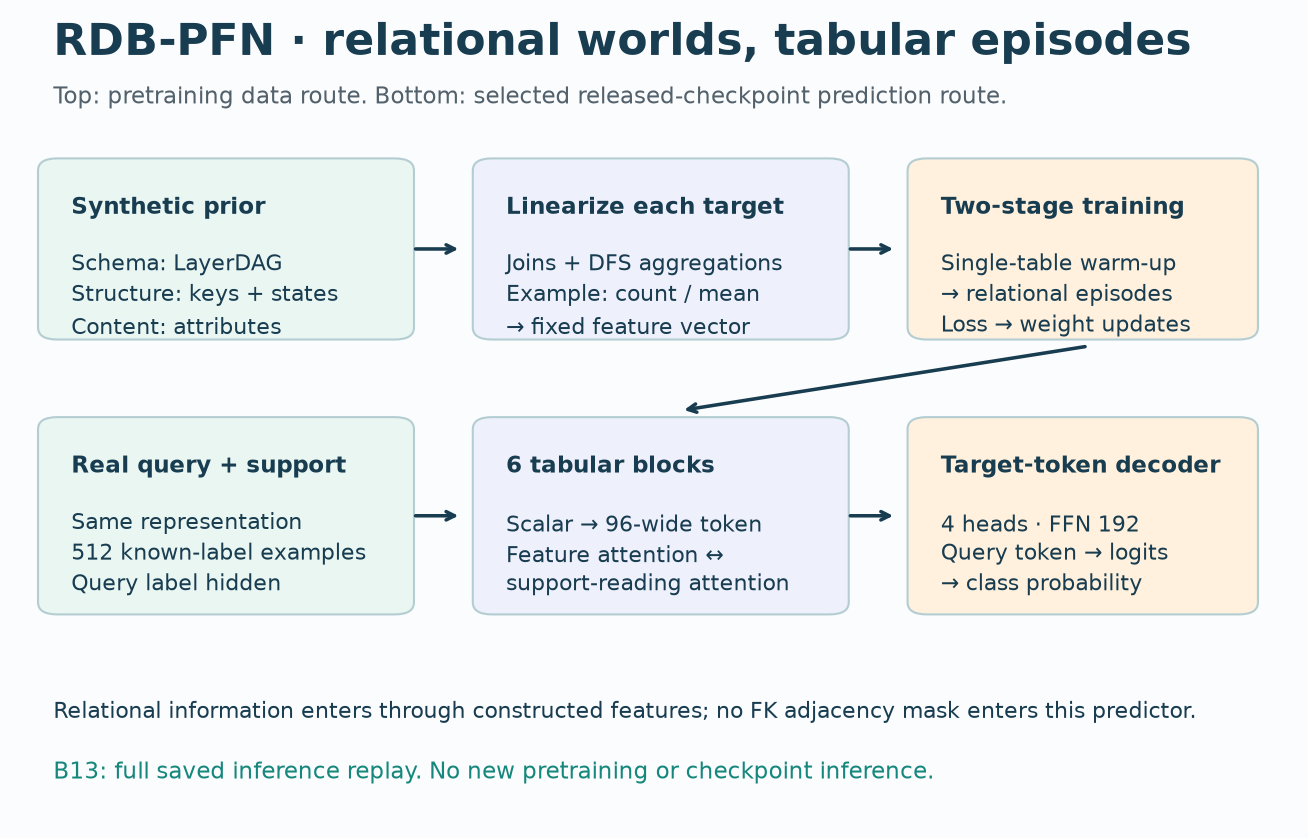

**Linearization** converts each target entity's relational neighborhood into a fixed-length vector. Deep Feature Synthesis (**DFS**) composes joins and aggregation operators, such as counts or means, along declared relationships. The model sees the resulting columns rather than receiving the original foreign-key graph as an inference-time attention mask.

For the selected released model, each scalar feature becomes a 96-dimensional token. Support-derived normalization prevents the query population from determining preprocessing statistics. Labels enter a separate target token for support rows; query targets are hidden. Six blocks alternate attention across feature tokens and across examples. In the latter direction, support rows supply the readable keys/values. The query target token passes through a decoder to class probabilities. The archived model has 4 heads and a 192-wide feed-forward layer; those are the released checkpoint dimensions, not a claim about every appendix variant.

**What is learned?** The transformer weights learn from synthetic episodes. **What is engineered?** The relational-to-tabular representation decides which aggregates the transformer receives. If two neighborhoods have identical retained counts and means but differ in an omitted property, this representation cannot let the learner distinguish that property.

> **Scope check.** The notebook includes the full visible selected RDB-PFN model and executable source evaluator. B13 replays saved checkpoint predictions; it does not rerun synthetic pretraining, LayerDAG training, or full DFS construction.


## 3 · PluRel: generate databases for a relational learner

Read [PluRel v1 §2, Figure 2, and §3](https://arxiv.org/html/2602.04029v1). **PluRel is a generator framework; RT is the learner used to test it.** This distinction remains useful even if a future learner consumes the same generated databases.

### Three stages, two graph scales

**Schema stage.** Sample a directed acyclic schema and row/column counts. The published implementation does not support schema cycles. A generated table graph describes possible table relationships, not the exact row connections.

**Foreign-key stage.** Populate links between parent and child rows. A **bipartite graph** connects two disjoint sets of nodes, here rows from two tables. PluRel uses hierarchical block structure to create clustered connectivity. This lets fanout and locality vary instead of forcing every child to choose a uniformly random parent.

**Value stage.** Visit tables in topological order, so a parent's values exist before a child needs them. Numeric and categorical values are projected into a common latent space, combined with parent information and noise, then reconstructed into their original types. Temporal source inputs can include trends, cycles, and fluctuations. Acyclic generation is a practical constraint, not evidence that enterprise databases cannot contain cycles.

### Model architecture · masked cells remain relational

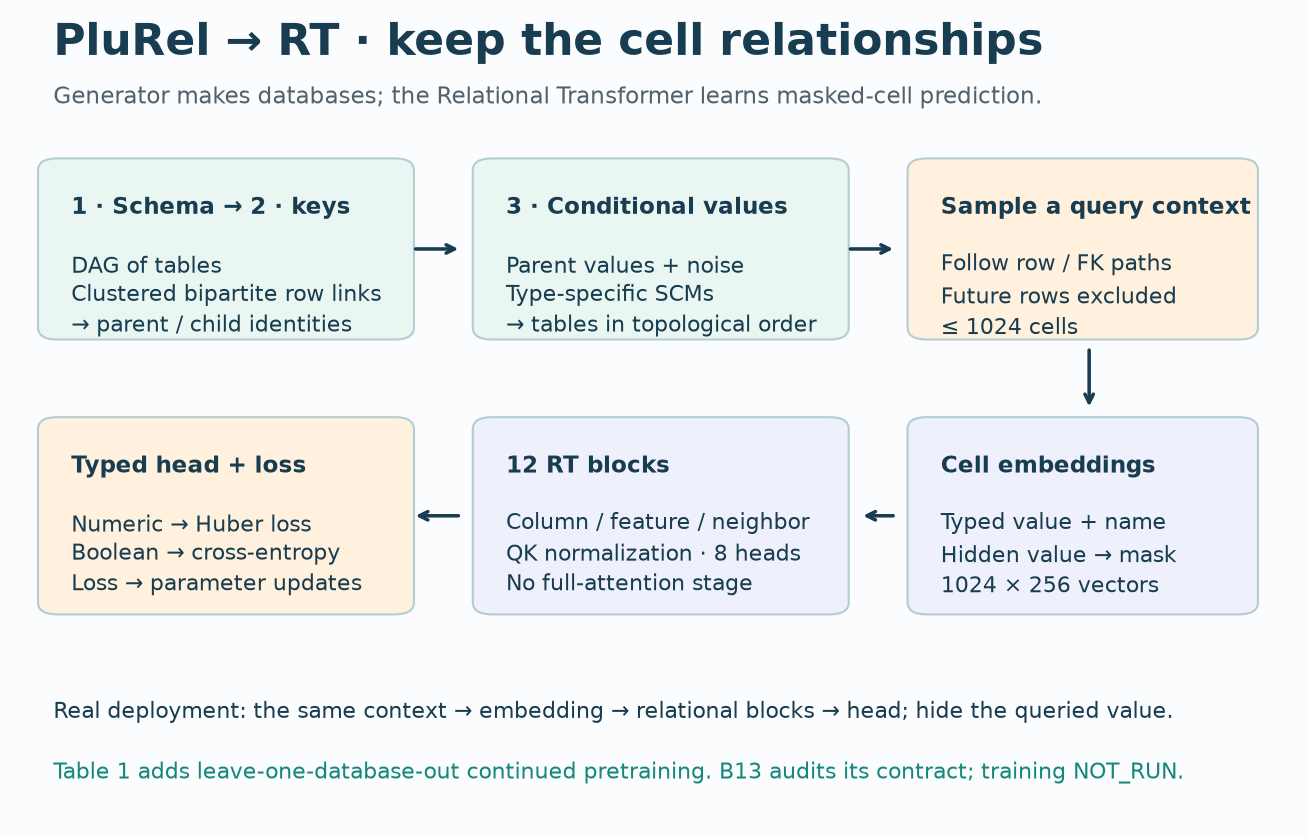

A **token** is one model input position; RT uses cells as tokens. A sampler follows foreign-key relationships from a query row, filters future-dated rows, and stops at a 1024-cell budget. A typed value embedding combines with table/column-name information. A masked target gets a learned mask embedding instead of its hidden value.

In the PluRel paper configuration,12 blocks operate on 256-wide vectors with 8 attention heads. **Column attention** reads cells in the same column. **Feature attention** reads the same row and linked parent rows. **Neighbor attention** reads linked child rows. These masks preserve distinct relational paths. The paper removes the unrestricted full-attention stage and normalizes queries and keys to stabilize training. A type-specific head predicts the masked value: classification uses cross-entropy, while numeric prediction uses Huber loss, which is quadratic near zero error and linear for large errors.

**Synthetic-only** means train on generated databases and then evaluate. **Synthetic+Real** means continue pretraining on real databases after synthetic pretraining. For Table 1, the evaluated database is excluded from this continued training. **Real-only** trains the same comparison architecture on the other real databases from random initialization. The selected task checkpoint comes from validation, not the test score.

> **Scope check.** The preserved paper source is available. The current Hub root model is a later release, and its task-specific leaderboard checkpoints do not automatically reproduce the original three-seed Table 1 protocol. Read the pinned source and deviation ledger before using them.


## 4 · A worked trace: keep the key, change the value read

**Worked example.** ParentA contains scalar values[2,6]. ParentB contains[10,14]. A query has local feature x0=4 and keys selecting A row 0 and B row 1. The parent mean is(2+14)/2=8. Our course target's noise-free rule gives 0.5×4+8=10. Changing the Akey to row 1 gives(6+14)/2=10, hence prediction 12.

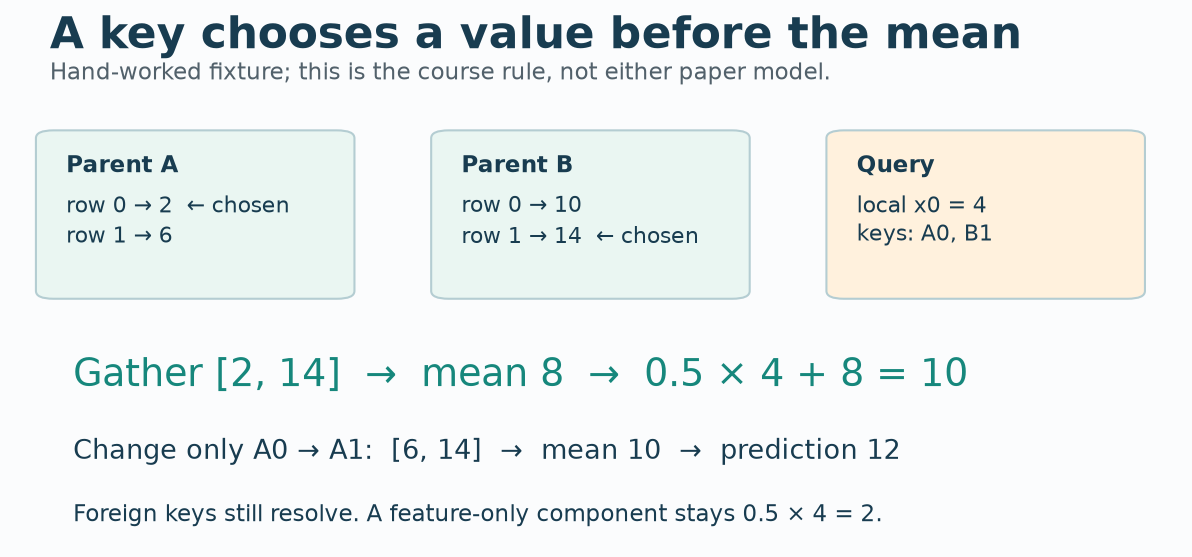

The three-row checker extends this trace: Akeys[0,1,1], Bkeys[1,0,1] produce parent means[8,8,10]. A join must gather by the keys; simply averaging each whole parent table gives the wrong answer.

**Recall / predict before reading:** distinguish the generated database, its representation, and the learner. Does renaming change topology? Must diversity help when the right feature is already supplied?

The feature-only rule cannot see a foreign-key intervention. The relational feature rule can. That demonstrates **information access**, not a learned relational architecture. The target rule was deliberately chosen to depend on the parent mean.


## 5 · Hold out structure, not spelling

A fresh database seed changes sampled values and links. It does not necessarily create a new schema. Two schemas are **isomorphic** when a one-to-one renaming of their tables preserves every directed edge. A schema holdout must reject these renamed copies too.

**Recall / predict before reading:** distinguish the generated database, its representation, and the learner. Does renaming change topology? Must diversity help when the right feature is already supplied?

Our exact checker tries all 24 renamings of four tables and chooses a canonical sorted edge list. A chain, out-star, in-star and diamond have distinct identities under this test. This factorial-time check is for tiny teaching graphs, not a scalable production graph-isomorphism algorithm. With real typed schemas, structural identity alone is only one part of a holdout policy; table types, shared source families and provenance can matter too.

**Three different budgets.** More schema families change structural variety. More databases can add new parameter draws even with the same schema. More rows/cells increase available observations. PluRel's paper varies database count and pretraining-token count separately. Our course experiment fixes 12 databases and 12,288 numeric feature cells per training arm, varying the number of schema families. Those are related questions, not identical experiments.


## 6 · Run the controlled experiment before making a scaling claim

**Held fixed:** three paired seeds,12 training databases per arm,4 tables×64 rows×4 attributes per database, the target rule, ridge penalty 1, training-only normalization, and the same 256 held-out queries per seed. Ridge regression fits a linear predictor with a penalty on squared coefficient size; the intercept is not penalized.

**Varied:** one schema family versus three, and query attributes alone versus query attributes plus the parent mean. Four new diamond databases form the test set; no test labels enter fitting or tuning. Training has 3 edges per schema while diamond has 4, so the holdout also changes connectivity degree. Keys and target-label cells are additional to the stated numeric-feature budget and are counted in the contract.

**Measured:** mean squared error (**MSE**) averages squared prediction errors over every test query. We retain all 3,072 intact predictions and 3,072 additional predictions after shuffling each target-table FK column. Each shuffle preserves the key multiset, so all keys still resolve and parent fanouts stay fixed. Ground truth and trained coefficients do not change. These extra predictions require no refitting.

**Recall / predict before reading:** distinguish the generated database, its representation, and the learner. Does renaming change topology? Must diversity help when the right feature is already supplied?

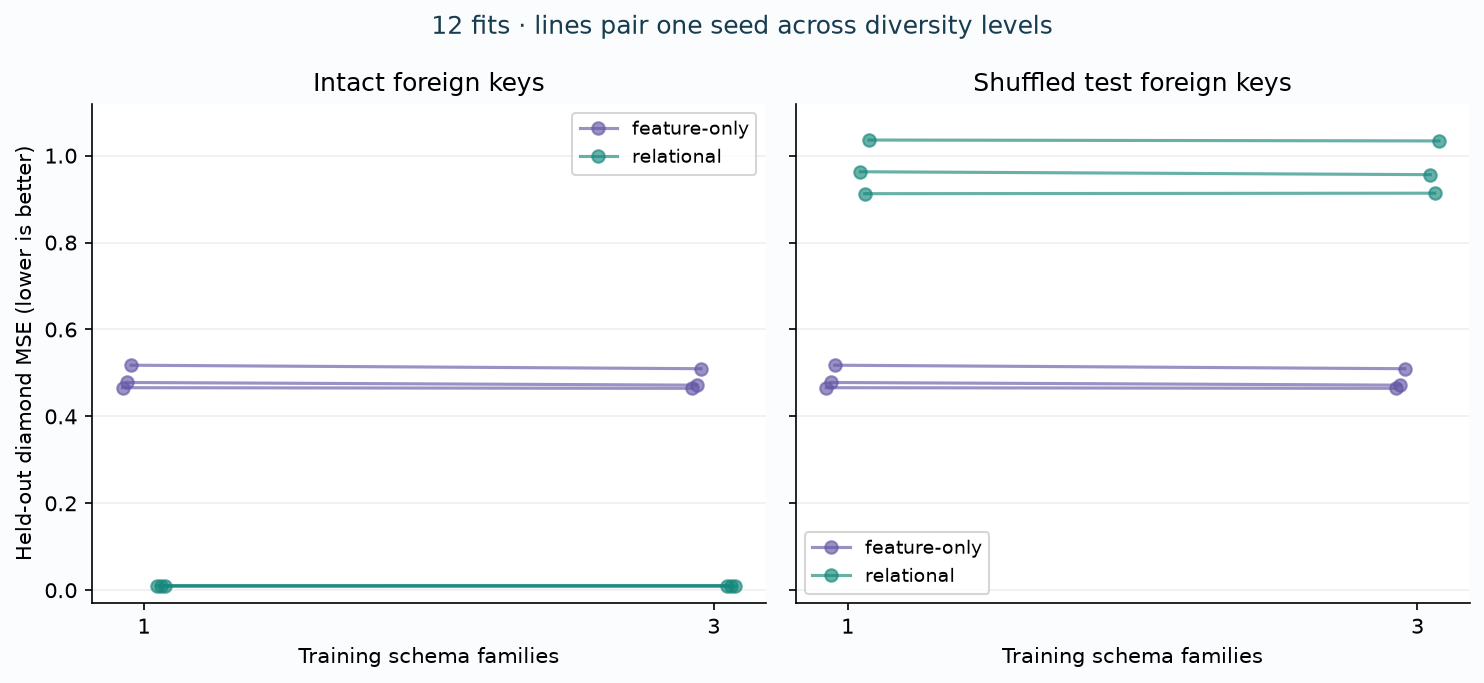

| Predictor | Training families | Intact MSE mean ± SD | Shuffled-FK MSE mean ± SD |
|---|---:|---:|---:|
| feature-only | 1 | 0.48727 ± 0.02708 | 0.48727 ± 0.02708 |
| feature-only | 3 | 0.48204 ± 0.02426 | 0.48204 ± 0.02426 |
| relational | 1 | 0.00997 ± 0.00068 | 0.97045 ± 0.06209 |
| relational | 3 | 0.00998 ± 0.00068 | 0.96791 ± 0.06096 |

Measured author evidence. SD uses three seed values; it is not a confidence interval. Lower MSE is better.

**Interpretation.** Adding the parent-mean feature greatly improves this constructed task. Shuffling the foreign keys destroys that advantage. Increasing training schema-family diversity does not consistently improve the relational arm. The feature-only arm improves slightly across these three seeds, but the changes are small and this is one constructed target family.

**Why no robust diversity gain?** The readout already computes the sufficient parent statistic, and the same linear equation governs training and test. This makes a new topology easy without learning a new structural rule. It is evidence about this controlled representation, not a refutation of PluRel's scaling results and not proof of RFM transfer.

> **Scope check.** These are three seed values on one synthetic design. SampleSD is descriptive variability, not a confidence interval. Real-database transfer, general superiority and whole-paper reproduction remain untested here.


## 7 · Full reproduction: name the result and its boundary

### RDB-PFN · complete selected saved-evidence replay

The selected target is **v5 Table 9, rel-f1/driver-dnf**, three released-model configurations × ten paired 512-row supports × 702 queries. The new pairwise AUROC audit reconstructs the support draws, authenticates complete(driverId,date)keys, checks every receipt, and rescores all 21,060 predictions. **AUROC** is the fraction of positive-negative pairs ranked correctly, with half credit for ties.

| Released configuration | Replayed AUROC mean ± SD | v5 paper target |
|---|---:|---:|
| RDBPFN | 0.721938 ± 0.019983 | 0.7219 |
| RDBPFN_single | 0.663990 ± 0.034177 | 0.6640 |
| TabICLv1.1 | 0.717568 ± 0.009770 | 0.7176 |

Ten support draws on one fixed test population; SD is across supports. All means are within the predeclared descriptive tolerance 0.02.

These are the same immutable predictions freshly generated in L200; they are not new B13 inference. The released target orientation is opposite the current raw DNF indicator. Numerical agreement does not certify full DFS provenance or historical feature availability. Ten support draws on one test population do not count as ten independent datasets.

### PluRel · full Table 1 contract, execution gated

The target retains all 18 tasks and three seeds for Real-only and Synthetic+Real. This means 36 leave-one-database-out training runs and 108 task/arm/seed evaluations, plus synthetic-base pretraining if reconstructing it from scratch. The base uses 1,024 synthetic databases and 4B tokens. This scope is separate from the full scaling grid.

We located the official source, author-designated paper tag, generator, sampler, model, trainer and synthetic checkpoints. But the public scripts specify seed 0; the complete three-seed historical mapping is unresolved. The Hub card describes later continued/finetuned checkpoints selected with validation NMAE for regression, which is not Table 1'sR² selection. The paper source uses a linear learning-rate schedule; the later card describes cosine. Those differences forbid silently substituting the later run.

Published Table 1 numbers are preserved for all 18 tasks in the source packet, clearly marked as published targets. B13 does not run those training jobs or download their weights. Status: **INCOMPLETE_SOURCE_PROTOCOL_AND_BUDGET_GATE**. The full scripts remain readable and executable once their prerequisites and budget are satisfied; we have not manufactured missing seeds.

**Budget and evidence:** USD 0 paid execution;3,600 aggregate local execution seconds. Full protocol, commands and deviations (included in the extracted source/evidence packet) · course result (included in the extracted source/evidence packet) · RDB-PFN replay (included in the extracted source/evidence packet) · PluRel target inventory (included in the extracted source/evidence packet).



## TODO 1 · canonical_schema

Try all table permutations; preserve edge directions, reject duplicates/self-loops/cycles/dangling nodes. Return the lexicographically smallest sorted edge tuple. Four-node factorial enumeration is intentional.

In [2]:
def canonical_schema(edges, n=4):
    """Exact directed unlabeled graph identity, practical only for tiny graphs."""
    edges=[tuple(e) for e in edges]
    if not 1<=n<=7 or len(set(edges))!=len(edges):raise ValueError('Invalid graph size or duplicates')
    if any(len(e)!=2 or any(type(v) is not int or not 0<=v<n for v in e) or e[0]==e[1] for e in edges):raise ValueError('Invalid edge')
    remaining=set(range(n))
    while remaining:
        roots={v for v in remaining if not any(b==v and a in remaining for a,b in edges)}
        if not roots:raise ValueError('Cyclic schema unsupported')
        remaining-=roots
    return min(tuple(sorted((p[a],p[b]) for a,b in edges)) for p in itertools.permutations(range(n)))

In [3]:
def test_schema():
    chain=[(0,1),(1,2),(2,3)]
    reference=canonical_schema(chain)
    for p in itertools.permutations(range(4)):
        assert canonical_schema([(p[a],p[b]) for a,b in chain])==reference
    assert canonical_schema([(0,1),(0,2),(0,3)])!=reference
    for bad in [[(0,1),(1,0)],[(0,0)],[(0,4)],[(0,1),(0,1)]]:
        try:canonical_schema(bad)
        except ValueError:pass
        else:raise AssertionError('Invalid graph admitted')
test_schema()
print("CHECK passed: canonical_schema")

CHECK passed: canonical_schema


## TODO 2 · parent_mean

Gather each parent array using its aligned child foreign-key array, then average gathered values across parents. Reject invalid indices and nonfinite attributes. Do not average whole tables.

In [4]:
def parent_mean(values, foreign_keys):
    """Mean of direct-parent scalar attributes, one gathered value per FK."""
    if not values or len(values)!=len(foreign_keys):raise ValueError('Aligned nonempty parents required')
    gathered=[]
    for v,k in zip(values,foreign_keys):
        v=np.asarray(v,dtype=float);k=np.asarray(k)
        if v.ndim!=1 or k.ndim!=1 or k.dtype.kind not in 'iu' or not np.isfinite(v).all() or np.any(k<0) or np.any(k>=len(v)):raise ValueError('Invalid foreign key/value')
        if gathered and len(k)!=len(gathered[0]):raise ValueError('Unaligned child rows')
        gathered.append(v[k])
    return np.mean(np.stack(gathered),axis=0)

In [5]:
def test_parent_mean():
    values=[np.array([2.,6.]),np.array([10.,14.])]
    keys=[np.array([0,1,1]),np.array([1,0,1])]
    np.testing.assert_array_equal(parent_mean(values,keys),[8.,8.,10.])
    try:parent_mean(values,[np.array([2,0,1]),keys[1]])
    except ValueError:pass
    else:raise AssertionError('Dangling FK accepted')
test_parent_mean()
print("CHECK passed: parent_mean")

CHECK passed: parent_mean


## TODO 3 · fit_ridge

Fit mean and population SD on training X only; use scale1 for constant columns. Center y, solve regularized normal equations with alpha>0 and unpenalized mean intercept. Return mean, scale, coef, intercept. No query arrays are inputs.

In [6]:
def fit_ridge(x, y, alpha=1.0):
    """Train-only population normalization; unpenalized target mean/intercept."""
    x=np.asarray(x,dtype=float);y=np.asarray(y,dtype=float)
    if x.ndim!=2 or y.shape!=(len(x),) or len(x)==0 or not np.isfinite(x).all() or not np.isfinite(y).all() or not np.isfinite(alpha) or alpha<=0:raise ValueError('Invalid ridge inputs')
    mean=x.mean(0);scale=x.std(0);scale=np.where(scale==0,1.,scale)
    z=(x-mean)/scale;intercept=float(y.mean())
    coef=np.linalg.solve(z.T@z+alpha*np.eye(x.shape[1]),z.T@(y-intercept))
    return dict(mean=mean,scale=scale,coef=coef,intercept=intercept)

In [7]:
def test_ridge():
    # Standardized x has variance1. With alpha2, coefficient=2/(2+2)=.5.
    model=fit_ridge(np.array([[-1.],[1.]]),np.array([-1.,1.]),2.)
    np.testing.assert_allclose(model['coef'],[.5],atol=1e-14)
    np.testing.assert_allclose(model['mean'],[0.]);np.testing.assert_allclose(model['scale'],[1.])
    const=fit_ridge(np.ones((3,1)),np.array([1.,2.,3.]))
    np.testing.assert_array_equal(const['coef'],[0.]);assert const['intercept']==2.
test_ridge()
print("CHECK passed: fit_ridge")

CHECK passed: fit_ridge


## PROVIDED · Schema family and generator

Four independent attributes per row; keys choose parent values. The target depends on the same parent-mean statistic at train and test. This is an intentionally easy transfer rule, not PluRel's full clustered temporal SCM. Your `canonical_schema` and `parent_mean` functions are called here.

In [8]:
SCHEMAS={'chain':[(0,1),(1,2),(2,3)],'out-star':[(0,1),(0,2),(0,3)],
         'in-star':[(0,3),(1,3),(2,3)],'diamond':[(0,1),(0,2),(1,3),(2,3)]}

def generate_database(seed, family, rows=64):
    """Course SCM: four independent numeric attributes/table plus a relational target.

    4*rows*4 feature cells. PK/FK cells and 64 target labels are additional.
    Separate RNG streams keep exogenous draws paired across schema interventions.
    """
    edges=SCHEMAS[family];canonical_schema(edges)
    x=np.random.default_rng(seed).normal(size=(4,rows,4))
    fk={}
    for a,b in edges:
        rng=np.random.default_rng(np.random.SeedSequence([seed,11,a,b]))
        fk[(a,b)]=rng.integers(rows,size=rows)
    parents=[a for a,b in edges if b==3]
    signal=parent_mean([x[a,:,0] for a in parents],[fk[(a,3)] for a in parents])
    noise=np.random.default_rng(np.random.SeedSequence([seed,29])).normal(0,.1,rows)
    return dict(seed=seed,family=family,x=x,fk=fk,y=.5*x[3,:,0]+signal+noise)

## PROVIDED · Target-free readout and predictor

Your gather feeds the actual relational feature. The predictor never reads database target labels. Each corrupted FK column keeps the same multiset; targets stay fixed.

In [9]:
def features(db, relational, corrupt=False):
    """No target reads. Corruption preserves each FK column's multiset."""
    x=db['x'];base=x[3].copy()
    if not relational:return base
    parents=[a for a,b in SCHEMAS[db['family']] if b==3];keys=[]
    for a in parents:
        k=db['fk'][(a,3)].copy()
        if corrupt:
            rng=np.random.default_rng(np.random.SeedSequence([db['seed'],97,a]))
            k=k[rng.permutation(len(k))]
        keys.append(k)
    return np.column_stack([base,parent_mean([x[a,:,0] for a in parents],keys)])

def predict(model,x):
    return (x-model['mean'])/model['scale']@model['coef']+model['intercept']

## CHECK · All 12 fits

The runner calls your fit function. Twelve training databases per arm; four new diamond test databases per seed. Do not tune alpha using these test results.

In [10]:
def run_experiment():
    """12 fixed fits. All test interventions reuse the intact-trained coefficients."""
    training=['chain','out-star','in-star']
    assert canonical_schema(SCHEMAS['diamond']) not in [canonical_schema(SCHEMAS[s]) for s in training]
    results=[]
    for seed in range(3):
        tests=[generate_database(100000+seed*100+i,'diamond') for i in range(4)]
        for diversity in [1,3]:
            dbs=[generate_database(seed*100+i,training[i%diversity]) for i in range(12)]
            assert sum(d['x'].size for d in dbs)==12288
            for relational in [False,True]:
                x=np.concatenate([features(d,relational) for d in dbs]);y=np.concatenate([d['y'] for d in dbs])
                model=fit_ridge(x,y,1.)
                keys=[[d['seed'],3,i] for d in tests for i in range(64)]
                target=np.concatenate([d['y'] for d in tests])
                p=predict(model,np.concatenate([features(d,relational) for d in tests]))
                broken=predict(model,np.concatenate([features(d,relational,True) for d in tests]))
                results.append(dict(seed=seed,diversity=diversity,arm='relational' if relational else 'feature-only',
                    training_seeds=[d['seed'] for d in dbs],training_families=[d['family'] for d in dbs],
                    training_feature_cells=12288,training_target_cells=768,keys=keys,labels=target.tolist(),
                    predictions=p.tolist(),corrupted_predictions=broken.tolist(),
                    mse=float(np.mean((p-target)**2)),corrupted_mse=float(np.mean((broken-target)**2)),
                    model={k:v.tolist() if isinstance(v,np.ndarray) else v for k,v in model.items()}))
    return dict(experiment='B13 held-out diamond course diagnostic',status='COMPLETE_COURSE_EXPERIMENT',
                fits=12,intact_predictions=3072,corrupted_predictions=3072,conditions=results,
                paper_model_reproduction=False,held_out_family='diamond')
report=run_experiment()
print(report["status"],report["fits"],report["intact_predictions"],report["corrupted_predictions"])

COMPLETE_COURSE_EXPERIMENT 12 3072 3072


## CHECK · Independent readout and SVD oracle

Independent scalar gathers and an augmented least-squares solution check every saved prediction. Replacing query labels must leave features unchanged.

In [11]:
def scalar_features(db,relational,corrupt=False):
    parents=[a for a,b in SCHEMAS[db['family']] if b==3];keys={}
    for a in parents:
        k=db['fk'][(a,3)]
        if corrupt:k=k[np.random.default_rng(np.random.SeedSequence([db['seed'],97,a])).permutation(len(k))]
        keys[a]=k
    rows=[]
    for i in range(len(db['y'])):
        row=list(db['x'][3,i])
        if relational:row.append(sum(float(db['x'][a,keys[a][i],0]) for a in parents)/len(parents))
        rows.append(row)
    return np.array(rows)

def verify(report):
    assert report['fits']==12 and report['intact_predictions']==3072 and report['corrupted_predictions']==3072
    expected={(s,d,a) for s in range(3) for d in [1,3] for a in ['relational','feature-only']}
    if len(report['conditions'])!=12 or {(r['seed'],r['diversity'],r['arm']) for r in report['conditions']}!=expected:raise ValueError('Incomplete course grid')
    errors=[];count=0
    for r in report['conditions']:
        seed=r['seed'];div=r['diversity'];rel=r['arm']=='relational';families=['chain','out-star','in-star']
        dbs=[generate_database(seed*100+i,families[i%div]) for i in range(12)]
        assert r['training_seeds']==[d['seed'] for d in dbs] and r['training_families']==[d['family'] for d in dbs]
        assert r['training_feature_cells']==sum(d['x'].size for d in dbs)==12288
        assert r['training_target_cells']==sum(d['y'].size for d in dbs)==768
        test=[generate_database(100000+seed*100+i,'diamond') for i in range(4)]
        assert r['keys']==[[d['seed'],3,i] for d in test for i in range(64)]
        x=np.concatenate([scalar_features(d,rel) for d in dbs]);y=np.concatenate([d['y'] for d in dbs])
        mu=x.mean(0);sd=x.std(0);sd[sd==0]=1;z=(x-mu)/sd
        # Solve augmented regression with SVD, independent of normal equations.
        coef=np.linalg.lstsq(np.vstack([z,np.eye(z.shape[1])]),np.r_[y-y.mean(),np.zeros(z.shape[1])],rcond=None)[0]
        np.testing.assert_allclose(coef,r['model']['coef'],atol=1e-12,rtol=1e-12)
        for field,value in [('mean',mu),('scale',sd),('intercept',y.mean())]:np.testing.assert_allclose(r['model'][field],value,atol=1e-12,rtol=1e-12)
        truth=np.concatenate([d['y'] for d in test]);np.testing.assert_array_equal(r['labels'],truth)
        for corrupt,pkey,mkey in [(False,'predictions','mse'),(True,'corrupted_predictions','corrupted_mse')]:
            tx=np.concatenate([scalar_features(d,rel,corrupt) for d in test])
            oracle=(tx-mu)/sd@coef+y.mean();saved=np.array(r[pkey])
            np.testing.assert_allclose(saved,oracle,atol=1e-12,rtol=1e-12)
            mse=sum((float(p)-float(t))**2 for p,t in zip(saved,truth))/len(truth)
            assert abs(mse-r[mkey])<1e-12;count+=len(saved)
        if not rel:assert r['predictions']==r['corrupted_predictions']
        for d in test:
            before=features(d,rel);changed=copy.deepcopy(d);changed['y'][:]=1e9
            np.testing.assert_array_equal(before,features(changed,rel))
        errors.append(float(np.max(np.abs(coef-np.array(r['model']['coef'])))))
    assert len({canonical_schema(e) for e in SCHEMAS.values()})==4
    for edges in SCHEMAS.values():
        for perm in itertools.permutations(range(4)):
            assert canonical_schema([(perm[a],perm[b]) for a,b in edges])==canonical_schema(edges)
    return dict(status='PASS',fits=12,predictions_checked=count,svd_coefficient_max_error=max(errors),target_intervention='PASS',feature_only_fk_invariance='PASS',exact_unlabeled_topology_separation='PASS')
verification=verify(report)
print(verification)

{'status': 'PASS', 'fits': 12, 'predictions_checked': 6144, 'svd_coefficient_max_error': 1.5543122344752192e-15, 'target_intervention': 'PASS', 'feature_only_fk_invariance': 'PASS', 'exact_unlabeled_topology_separation': 'PASS'}


In [12]:
for r in report["conditions"]:
    print(r["seed"],r["diversity"],r["arm"],"MSE",round(r["mse"],6),"shuffled",round(r["corrupted_mse"],6))
(workspace/"course-results.json").write_text(json.dumps(report,indent=2))

0 1 feature-only MSE 0.466031 shuffled 0.466031
0 1 relational MSE 0.010213 shuffled 0.962938
0 3 feature-only MSE 0.464509 shuffled 0.464509
0 3 relational MSE 0.010263 shuffled 0.956244
1 1 feature-only MSE 0.478025 shuffled 0.478025
1 1 relational MSE 0.010487 shuffled 0.912464
1 3 feature-only MSE 0.471877 shuffled 0.471877
1 3 relational MSE 0.010479 shuffled 0.913625
2 1 feature-only MSE 0.517769 shuffled 0.517769
2 1 relational MSE 0.0092 shuffled 1.035959
2 3 feature-only MSE 0.50972 shuffled 0.50972
2 3 relational MSE 0.009213 shuffled 1.033864


481155

## EXIT · Defend the mechanism

Explain why an engineered sufficient statistic can transfer across a held-out topology without learned graph reasoning. Separate schemas, database draws and cells. Trace both paper pipelines, name two falsification tests, and explain why the corruption experiment tests use of keys rather than universal superiority. Revisit after1/7/30days. Ask the teaching agent for feedback; PENDING_WRITTEN_DEFENSE remains until you defend your work.

## NEXT STEP · Complete selected RDB-PFN replay

This cell extracts immutable L200 evidence into a fresh directory, then uses a new positive-negative pair oracle. It authenticates keys, labels, support derivation and all30evaluations. The same saved predictions are replayed; no model inference occurs.

In [13]:
def pairwise_auc(y,p):
    y=np.asarray(y);p=np.asarray(p,dtype=float)
    if y.shape!=p.shape or y.ndim!=1 or set(y.tolist())!={0,1} or not np.isfinite(p).all() or np.any((p<0)|(p>1)):raise ValueError('Invalid binary predictions')
    delta=p[y==1,None]-p[y==0][None,:]
    return float(np.mean((delta>0)+.5*(delta==0)))

def audit_l200(root):
    root=Path(root);manifest=json.loads((root/'packet-manifest.json').read_text())
    for name,digest in manifest['files'].items():
        if hashlib.sha256((root/name).read_bytes()).hexdigest()!=digest:raise ValueError('Changed inherited bytes: '+name)
    data=np.load(root/'packet/prepared.npz',allow_pickle=False)
    if tuple(data['test_keys'].shape)!=(702,2) or len(set(map(tuple,data['test_keys'])))!=702:raise ValueError('Missing full query identities')
    if len(data['train_keys'])!=11411 or len(set(map(tuple,data['train_keys'])))!=11411:raise ValueError('Training population changed')
    for seed in range(10):
        derived=int.from_bytes(hashlib.sha256(f'rel-f1-dfs-2:driver-dnf:{seed}'.encode()).digest()[:4],'big')
        expected=np.random.default_rng(derived).choice(11411,512,replace=False)
        if not np.array_equal(expected,data['support'][seed]):raise ValueError('Support draw derivation changed')
    arms=['RDBPFN','RDBPFN_single','TabICLv1.1'];records={};count=0
    for phase in ['pilot-1','full-1']:
        receipt=json.loads((root/phase/'receipt.json').read_text())
        if receipt['input_manifest_sha256']!=manifest['input_manifest_sha256']:raise ValueError('Input identity changed')
        for r in receipt['records']:
            key=(r['arm'],r['seed'])
            if key in records:raise ValueError('Duplicate evaluation')
            p=root/phase/f"{r['arm']}-{r['seed']}.npz"
            if hashlib.sha256(p.read_bytes()).hexdigest()!=r['sha256']:raise ValueError('Prediction receipt mismatch')
            x=np.load(p,allow_pickle=False)
            for a,b in [(x['keys'],data['test_keys']),(x['label'],data['y_test']),(x['support_keys'],data['train_keys'][data['support'][r['seed']]])]:
                if not np.array_equal(a,b):raise ValueError('Key, target, or support mismatch')
            if len(set(map(tuple,x['support_keys'])))!=512 or set(map(tuple,x['keys']))&set(map(tuple,x['support_keys'])):raise ValueError('Support/query overlap')
            score=pairwise_auc(x['label'],x['probability'])
            if abs(score-r['auc'])>1e-12:raise ValueError('Receipt AUROC disagreement')
            records[key]=score;count+=len(x['label'])
    if set(records)!={(a,s) for a in arms for s in range(10)} or count!=21060:raise ValueError('Incomplete grid')
    models={}
    for arm,target in zip(arms,[.7219,.6640,.7176]):
        scores=[records[arm,s] for s in range(10)]
        models[arm]=dict(per_seed=scores,mean=float(np.mean(scores)),sample_sd=float(np.std(scores,ddof=1)),paper_target=target,status='CLOSE' if abs(np.mean(scores)-target)<=.02 else 'OUTSIDE_TOLERANCE')
    diffs=[records['RDBPFN',s]-records['TabICLv1.1',s] for s in range(10)]
    return dict(status='COMPLETE_SAVED_EVIDENCE_REPLAY',origin='L200 fresh released-checkpoint inference; B13 performs no new inference',evaluations=30,predictions=count,models=models,paired_rdbpfn_minus_tabicl=dict(mean=float(np.mean(diffs)),sample_sd=float(np.std(diffs,ddof=1)),per_seed=diffs),whole_paper='NOT_RUN',fresh_pretraining='NOT_RUN',historical_identity='NOT_ESTABLISHED',full_dfs_regeneration='NOT_RUN')

def replay_archive(archive):
    with tempfile.TemporaryDirectory(prefix='b13-l200-') as td:
        with zipfile.ZipFile(io.BytesIO(archive)) as z:
            if any(Path(n).is_absolute() or '..' in Path(n).parts for n in z.namelist()):raise ValueError('Unsafe archive paths')
            z.extractall(td)
        return audit_l200(Path(td)/'labs/evidence/l200')

In [14]:
archive=base64.b64decode('...')
assert hashlib.sha256(archive).hexdigest()=='17c0128e8cced6cd004c308878e9e506c4d4229298202b63051c69d16124f4fd'
replay=replay_archive(archive)
print(replay["status"],replay["evaluations"],replay["predictions"])
for arm,r in replay["models"].items():print(arm,r["mean"],r["sample_sd"])

COMPLETE_SAVED_EVIDENCE_REPLAY 30 21060
RDBPFN 0.7219377348362855 0.019982667847990538
RDBPFN_single 0.6639896550041476 0.03417677717319856
TabICLv1.1 0.7175684380032206 0.00976959545029791


## PROVIDED · Full source packet and fresh-inference route

The source packet preserves full upstream generator/model/trainer code, Rust sampler, licenses, pinned evidence preparation and complete inference operators. Its source manifest authenticates every file. Extracting code does not execute it. Commands and unresolved PluRel Table1 requirements are in `labs/b13-reproduction.md`. Fresh inference and full training are outside the default notebook and the approved paid budget.

In [15]:
archive=base64.b64decode('...')
assert hashlib.sha256(archive).hexdigest()=='6e47b5daed7776fdb9b3e5ef7131c77f7f22c1170069b026aba78a7bea8905bb'
source_root=workspace/'source-packet'
with zipfile.ZipFile(io.BytesIO(archive)) as z:
    assert all(not Path(n).is_absolute() and '..' not in Path(n).parts for n in z.namelist())
    z.extractall(source_root)
source_manifest=json.loads((source_root/'source-manifest.json').read_text())
for name,digest in source_manifest.items():assert hashlib.sha256((source_root/name).read_bytes()).hexdigest()==digest,name
print('Authenticated',len(source_manifest),'source files. Training NOT_RUN.')


Authenticated 359 source files. Training NOT_RUN.


## Full reproduction contract

# B13 · Synthetic relational data: reproduction contract

Approved 2026-10-03: USD0 paid execution and3600 aggregate local execution seconds. All preparation, failed attempts, reruns and delivery checks count. No cloud/API model calls. Numerical commands run through `_budget_b13.py`; exhausted budget stops as INCOMPLETE. Preparation allowance recorded separately. No change to the user's USD10 maximum for future costed proposals.

## Lane A: fresh course held-out-schema experiment

This is a Tier C diagnostic, not RDB-PFN, PluRel, RT, or a published benchmark. Source `relkit/synthetic_b13.py` is visible in the notebook. Three live learner functions are called by generation, feature construction and fitting.

Seeds0/1/2 × training diversity1/3 × feature-only/relational =12fits. Each arm has12databases with4tables,64rows/table,4standard-normal numeric attributes/row:12288generated numeric feature cells. Additional budget:3072PKcells,2304FKcells,768target cells per training arm. All training topologies have3edges. Generated arrays and noise are paired by seed across arms. FK RNG streams are fixed per edge. Key identifiers are integer row indices; allFKs resolve.

One-family training: directed chain0→1→2→3. Three-family training: four chains, four out-stars0→{1,2,3}, four in-stars{0,1,2}→3. Exact directed isomorphism enumerates all24node permutations. Test: four new diamond0→{1,2}→3databases per seed, never generated in training;256query rows per arm. Full identity=(database_seed,table3,row_id). Numeric-feature cell count is held fixed, not the attention-token count of either paper. The diamond has4edges, so this is also a connectivity-degree shift. Database count stays12; varying family count is not the paper's database-count scaling axis.

For table3, target y=.5*x0+mean(direct parents' gathered x0)+Gaussian noise withSD.1. Feature-only ridge reads the query's4attributes. Relational ridge also reads one hand-engineered parent-mean feature. This feature encodes the true target structure; it deliberately makes generalization easy. No claim of learned schema reasoning, universal relational transfer, or RFM superiority follows.

Ridge alpha1 fixed before scoring; population mean/SD fit on training only; zero scales→1; intercept unpenalized. No validation tuning/checkpoint selection. NumPy float64. Mean squared error on all256queries; report three seed values and sampleSD, not a confidence interval. Same model additionally predicts with each query-table FK column independently permuted, preserving FK counts and validity. Original truth stays fixed. No refit or new fit count. Store all3072intact and3072corrupted predictions. Independent scalar FK read, scalar MSE, SVD least-squares, hidden-target intervention and corruption rejection checks.

```sh
.venv/bin/python labs/_budget_b13.py .venv/bin/python labs/_test_b13.py
.venv/bin/python labs/_budget_b13.py .venv/bin/python labs/_run_b13.py
.venv/bin/python labs/_budget_b13.py .venv/bin/python labs/_verify_b13.py
```

## Lane B: complete saved-evidence replay of RDB-PFN v5 Table9

Origin: L200's complete selected released-checkpoint evaluation on rel-f1/driver-dnf. B13 authenticates its portable packet and independently scores all30evaluations/21060predictions. No new model inference or pretraining occurs. Paper v1 is the curriculum reading; Table9 target is explicitly v5, not v1's differently numbered table.

Unchanged source commit a95378225478daa262b85f180d482da7516b0af6; dataset d6a88c0a8cce79607cfc0fca0dcba78ba262ffad; TabICL checkpoint eaf789a9b25ee8486d6f48997ba076f850bbc30b. RDBPFN model_eval00528; single-table model_eval00360; TabICL0.1.3/v1.1 with32estimators.11,411train/566validation/702test. No validation tuning. Ten512-row support draws: first4bytes big-endianSHA256(rel-f1-dfs-2:driver-dnf:{s})→default_rng→choice without replacement. Same support for all3arms; global modelRNG42.

Support-only median imputation; all-missing→0. Support-only population normalization and±100clamp. Numeric category codes preserved. Float32 inference; query keys and labels excluded from features. Six blocks,width96,4heads,FFN192; retained source implementation and evaluator. Complete(driverId,date)query keys. AUROC targets.7219/.6640/.7176; mean/sampleSD and paired differences; descriptive mean-distance tolerance.02 is not statistical equivalence.

Independent replay uses positive-negative pair comparisons with half credit for ties, separate from L200's rank-based implementation. It reconstructs all support index draws and authenticates keys, labels, probabilities and immutable receipts. Released label orientation complements the current raw30-dayDNF indicator; do not call these probabilities raw DNF risk without complementing both probabilities and labels. Checkpoint width96 overrides appendix128. Full rawDFS regeneration and complete historical-availability authentication remain NOT_RUN/NOT_ESTABLISHED.

```sh
.venv/bin/python labs/_budget_b13.py .venv/bin/python labs/_audit_b13.py
```

**Executable fresh inference, not executed by B13:** the portable source archive preserves repository layout, full upstream code and prepared packet. From its extracted root in a separate Python3.11environment, install `labs/l166-requirements.txt` and Torch2.5.1, then:

```sh
python labs/_fetch_l166.py --out /tmp/b13-input
python labs/_run_l166.py --input /tmp/b13-input --out /tmp/b13-fresh
```

Default runs all30evaluations. Use a new output directory; no optional reduced-seed invocation establishes the complete selected target. New execution requires its own costed ledger; current approval is replay-only. The fresh path is inherited from completed L166/L200 execution, statically packaged here, not newly runtime-tested in B13.

## Lane C: PluRel v1 Table1 full-target audit

Primary target: all18tasks (10classification AUROC,8regressionR²) comparing Real-only and Synthetic+Real, three seeds each. Six leave-one-database-out folds ×2initializations ×3seeds =36real-data training runs, then108task/arm/seed test evaluations. Each fold trains on the other five databases' forecasting/autocomplete tasks. Validation selects the highest-scoring checkpoint separately for each task. Preserve full official test queries and temporal context filtering. Report mean and standard error across3seeds. The published table's rounded values are in `sources/b13/plurel-table1.json`; reported gains can differ from subtracting rounded cells.

Synthetic+Real starts from the1024synthetic-database/4Btoken model; reconstructing it from scratch is additional synthetic pretraining, not included in the36real-data runs. The paper selected this base using validation performance across scaling configurations; repeating the complete selection process expands scope beyond this fixed-base target. Synthetic-only is preserved as published context, not counted among the two approved comparison arms. Whole Figure1 scaling grid and whole-paper reproduction remain NOT_RUN.

RT:12blocks,width256,8heads,FFN1024,context1024cells,BFSwidth128; all-MiniLM-L12-v2 name/text encoder384dimensions. Column/feature/neighbor masks; omit full attention; per-head query/key RMS normalization. Masked numeric/boolean prediction with Huber/cross-entropy objectives. AdamW lr5e-4,weight decay.1,betas(.9,.999),eps1e-8; batch128; gradient clip1.0. Preserved scripts use50001steps and evaluation every2000steps, max_eval_steps80; verify exact evaluated populations before asserting full-test parity. The training code uses OneCycleLR with20%warmup and linear annealing. Do not substitute the later leaderboard model card's cosine description.

**Artifacts actually located:** official current PluRel source9ba86ee46d143fc32bc25ee9b0a5348a49e06af2 points to paper tagv1.0.0 at2a273cfd21933ee4893dfcb862a3edaed45ac665. Complete tagged archive includes generator, Rust sampler, RT model/trainer/scripts and lockfile. Hub `stanford-star/rt-plurel` revision0cac262c0fc95353372b2cf1d5c1b0a1e649a449 inventories original synthetic checkpoints under `paper/`. No checkpoint weights are downloaded in B13.

**Unresolved historical mapping:** public training scripts hard-code seed0; all three paper seed IDs and full per-seed weights/receipts are not established. The Hub card explicitly identifies continued/finetuned task checkpoints as June2026leaderboard additions; regression selection uses validationNMAE, not Table1R². Therefore their existence does not supply the historical three-seed Table1comparison. Current root `model.safetensors` is a later model; do not silently substitute it. Exact dataset/processed snapshot identity, task aliases, evaluation caps, base selection provenance and original preprocessing populations need authentication. Author-designated paper code is available; claiming all code or weights are missing would be false.

**Runnable upstream operators, preserved without modifications:** in the extracted tagged source, `pixi install`; `pixi run torchrun --standalone --nproc_per_node=1 scripts/baseline_pretrain.py`; synthetic base: `scripts/synthetic_pretrain.py`; continued: `scripts/cntd_pretrain.py`. These seed0 source entrypoints are not an automatically complete three-seed Table1operator. Set paths, authenticate data, supply verified three-seed configuration and resolve selection details before dispatch. Full archive rather than the reading-only extracted files is required for the Rust sampler.

```sh
.venv/bin/python labs/_reproduce_b13.py --audit
```

Paper reports roughly3B200hours per pretraining run; this is a published runtime, not a measured B13run or current price quote. No fresh cloud estimate or cost admission is claimed. Training status INCOMPLETE_SOURCE_PROTOCOL_AND_BUDGET_GATE; inference NOT_RUN; full-pretraining NOT_RUN. USD0approval explicitly excludes paid dispatch. No silent smaller-model/fewer-seed replacement.

## Delivery and learner boundaries

Portable notebook defaults run the course experiment and saved RDB-PFN replay; source appendices are readable model/trainer listings, not executed paper training. Successful notebook/browser/Pages checks certify delivery, not source-result parity, liveColab, deployment, historical identity, or learner mastery. Learner PENDING_WRITTEN_DEFENSE. Revisit schema/row/cell distinctions after1/7/30days.


## PROVIDED · Visible RDB-PFN selected model and training loop

These archival listings are readable source, not the course ridge model. L166 previously checked the visible numeric path against both released checkpoints; B13does not rerun that parity test. Upstream licensing is preserved in the packet. The model exposes normalization, feature/label encoders, attention axes and decoder. The trainer exposes synthetic episode fitting; fresh pretraining is NOT_RUN.

### Source reading map

Read RDB-PFN's feature/example attention to locate the tabular representation boundary. For PluRel, follow `dag.py` (schema) → `utils.py` (bipartite keys and typed projections) → `scm.py` (conditional values) → `dataset.py` (generation orchestration). Then inspect RT's relational masks and trainer. These complete reference listings are optional deeper reading after the short lab, and remain separate from the executed course generator.

### Visible released-shape RDB-PFN

Complete source listing, split at top-level definitions. Use the source reading map above to locate this stage. This appendix does not execute the generator or paper training.

```python
"""Visible L166 mechanisms. Course prior is deliberately small; model matches base release."""
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F

```

```python
def relational_prior(seed, parents=8, children=24, strength=1.0):
    """Course two-table SCM; not the released LayerDAG/selective-SCM generator."""
    if any(type(v) is not int or v<1 for v in [parents,children]) or not np.isfinite(strength):
        raise ValueError('Positive integer sizes and finite strength required')
    rng=np.random.default_rng(seed)
    latent=rng.normal(size=parents)
    foreign_keys=rng.integers(parents,size=children)
    noise=rng.normal(scale=.2,size=children)
    return dict(parent_ids=np.arange(parents),latent=latent,child_parent=foreign_keys,
                noise=noise,values=strength*latent[foreign_keys]+noise)

```

```python
def dfs_summary(parent_ids, child_parent, values):
    """One backward aggregation: COUNT and MEAN in the supplied parent order."""
    ids=list(parent_ids);fk=list(child_parent);v=np.asarray(values,dtype=float)
    if len(set(ids))!=len(ids) or len(fk)!=len(v) or v.ndim!=1 or not np.isfinite(v).all() or not set(fk)<=set(ids):
        raise ValueError('Unique parents, valid foreign keys and finite aligned values required')
    out=np.zeros((len(ids),2));lookup={key:i for i,key in enumerate(ids)}
    for key,value in zip(fk,v):
        out[lookup[key],0]+=1;out[lookup[key],1]+=value
    out[:,1]/=np.maximum(out[:,0],1)
    return out

```

```python
def context_mask(rows, support):
    """True means a key/value is visible: all receivers read support only."""
    if type(rows) is not int or type(support) is not int or not 0<support<=rows:
        raise ValueError('Require 0 < support <= rows, both integers')
    return np.broadcast_to(np.arange(rows)<support,(rows,rows)).copy()

```

```python
def normalize_support(x, support):
    """Released population-variance normalization before scalar-to-vector projection."""
    if x.ndim!=3 or not 0<support<=x.shape[1]:raise ValueError('B x N x F with nonempty support')
    z=x.unsqueeze(-1);train=z[:,:support];valid=~torch.isnan(train)
    count=valid.sum(1,keepdim=True).clamp(min=1)
    mean=torch.where(valid,train,0.).sum(1,keepdim=True)/count
    var=torch.where(valid,train-mean,0.).square().sum(1,keepdim=True)/count
    return ((torch.where(torch.isnan(z),mean,z)-mean)/torch.sqrt(var+1e-20)).clamp(-100,100)

```

```python
class FeatureEncoder(nn.Module):
    def __init__(self,width):
        super().__init__();self.linear_layer=nn.Linear(1,width)
    def forward(self,x,support):return self.linear_layer(normalize_support(x,support))

```

```python
class TargetEncoder(nn.Module):
    def __init__(self,width):
        super().__init__();self.linear_layer=nn.Linear(1,width)
    def forward(self,y,rows):
        # Query slots contain the support mean, never held-out query labels.
        padding=y.to(torch.float).mean(1,keepdim=True).repeat(1,rows-y.shape[1],1)
        return self.linear_layer(torch.cat([y,padding],1).unsqueeze(-1))

```

```python
class BiAttention(nn.Module):
    def __init__(self,width,heads,hidden):
        super().__init__()
        self.self_attention_between_features=nn.MultiheadAttention(width,heads,batch_first=True)
        self.self_attention_between_datapoints=nn.MultiheadAttention(width,heads,batch_first=True)
        self.linear1=nn.Linear(width,hidden);self.linear2=nn.Linear(hidden,width)
        self.norm1=nn.LayerNorm(width);self.norm2=nn.LayerNorm(width);self.norm3=nn.LayerNorm(width)
    def forward(self,x,support):
        b,n,f,d=x.shape
        z=x.reshape(b*n,f,d)
        z=self.norm1((z+self.self_attention_between_features(z,z,z)[0]).reshape(b,n,f,d))
        z=z.transpose(1,2).reshape(b*f,n,d)
        keys=z[:,:support]
        left=self.self_attention_between_datapoints(keys,keys,keys)[0]
        right=self.self_attention_between_datapoints(z[:,support:],keys,keys)[0]
        z=self.norm2((z+torch.cat([left,right],1)).reshape(b,f,n,d).transpose(1,2))
        return self.norm3(z+self.linear2(F.gelu(self.linear1(z))))

```

```python
class Decoder(nn.Module):
    def __init__(self,width,hidden):
        super().__init__();self.linear1=nn.Linear(width,hidden);self.linear2=nn.Linear(hidden,2)
    def forward(self,x):return self.linear2(F.gelu(self.linear1(x)))

```

```python
class RDBPFN(nn.Module):
    """Checkpoint-compatible numeric base: six blocks, 96 channels, four heads."""
    def __init__(self,width=96,heads=4,hidden=192,layers=6):
        super().__init__();self.feature_encoder=FeatureEncoder(width);self.target_encoder=TargetEncoder(width)
        self.transformer_blocks=nn.ModuleList([BiAttention(width,heads,hidden) for _ in range(layers)])
        self.decoder=Decoder(width,hidden)
    def forward(self,src,support):
        x,y=src
        if y.ndim==2:y=y.unsqueeze(-1)
        z=torch.cat([self.feature_encoder(x,support),self.target_encoder(y,x.shape[1])],2)
        for block in self.transformer_blocks:z=block(z,support)
        return self.decoder(z[:,support:,-1])
```

### RDB-PFN upstream training

Complete source listing, split at top-level definitions. Use the source reading map above to locate this stage. This appendix does not execute the generator or paper training.

```python
from __future__ import annotations

import time
import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Sequence

import torch
from accelerate import Accelerator
from torch import nn
from torch.utils.data import DataLoader

from .models import NanoTabPFNClassifier, NanoTabPFNModel


logger = logging.getLogger(__name__)


```

```python
class ColumnSubsetCache:
    def __init__(self, reuse_limit: int = 100):
        self._permutations: dict[int, list[tuple[torch.Tensor, int]]] = {}
        self._reuse_limit = max(1, reuse_limit)

    def reset(self):
        self._permutations.clear()

    def get_indices(
        self,
        available_cols: int,
        device: torch.device,
        required_cols: int | None = None,
    ) -> torch.Tensor:
        available_cols = int(max(0, available_cols))
        if available_cols <= 0:
            return torch.empty(0, dtype=torch.long, device=device)
        required = (
            available_cols
            if required_cols is None
            else min(required_cols, available_cols)
        )
        entries = self._permutations.setdefault(available_cols, [])
        if entries:
            perm, count = entries[0]
            if count < self._reuse_limit and perm.numel() >= required:
                entries[0] = (perm, count + 1)
                return perm[:required].to(device)
        new_perm = torch.randperm(available_cols, device=torch.device("cpu"))
        entries.insert(0, (new_perm, 1))
        if len(entries) > self._reuse_limit:
            entries.pop()
        return new_perm[:required].to(device)


_SUPPORTED_TRANSFORM_KINDS = {
    "abs",
    "cos",
    "gaussian",
    "interaction",
    "linear",
    "log",
    "reciprocal",
    "sin",
    "sqrt",
    "square",
    "tanh",
}
_DEFAULT_TRANSFORM_KINDS = tuple(sorted(_SUPPORTED_TRANSFORM_KINDS))
_TRANSFORM_MAX_ABS = 1e6


@dataclass
```

```python
class ColumnModificationConfig:
    noise_columns_range: tuple[int, int] = (0, 0)
    noise_high_cardinality_prob: float = 0.5
    noise_low_cardinality_max: int = 5
    noise_scale: float = 1.0
    transform_columns_range: tuple[int, int] = (0, 0)
    transform_scale_range: tuple[float, float] = (0.5, 2.0)
    transform_shift_range: tuple[float, float] = (-0.5, 0.5)
    transform_noise_scale: tuple[float, float] = (0.0, 0.0)


```

```python
def _normalize_int_range(
    value: int | Sequence[int] | None,
    default: tuple[int, int] = (0, 0),
) -> tuple[int, int]:
    if value is None:
        low, high = default
    elif isinstance(value, int):
        low = high = value
    else:
        try:
            if len(value) == 0:
                low, high = default
            elif len(value) == 1:
                low = high = int(value[0])
            else:
                low, high = int(value[0]), int(value[1])
        except TypeError:
            low, high = default
    if high < low:
        low, high = high, low
    return max(0, int(low)), max(0, int(high))


```

```python
def _sample_int_from_range(
    value: int | Sequence[int] | None, device: torch.device
) -> int:
    low, high = _normalize_int_range(value)
    if high <= low:
        return int(low)
    return int(torch.randint(low, high + 1, (1,), device=device).item())


```

```python
def _sample_float_from_range(
    value: float | Sequence[float] | None,
    device: torch.device,
    dtype: torch.dtype,
) -> torch.Tensor:
    low, high = float(value[0]), float(value[1])
    if high <= low:
        return torch.tensor(low, device=device, dtype=dtype)
    return (high - low) * torch.rand((), device=device, dtype=dtype) + low


```

```python
def _sample_feature_indices(
    usable_counts: torch.Tensor, num_columns: int, device: torch.device
) -> torch.Tensor:
    if num_columns <= 0:
        return torch.empty((usable_counts.shape[0], 0), device=device, dtype=torch.long)
    usable_counts = usable_counts.to(device=device, dtype=torch.long).clamp(min=1)
    rand = torch.rand(usable_counts.shape[0], num_columns, device=device)
    indices = torch.floor(rand * usable_counts.unsqueeze(1).to(torch.float32)).to(
        torch.long
    )
    indices = torch.minimum(indices, usable_counts.unsqueeze(1) - 1)
    return indices


```

```python
def _generate_noise_columns(
    x: torch.Tensor,
    num_noise: int,
    high_cardinality_prob: float,
    low_cardinality_max: int,
    noise_scale: float,
) -> torch.Tensor | None:
    if num_noise <= 0:
        return None
    batch_size, num_rows, _ = x.shape
    device = x.device
    dtype = x.dtype
    high_prob = float(max(0.0, min(1.0, high_cardinality_prob)))
    low_cardinality_max = max(1, int(low_cardinality_max))
    noise_scale = float(abs(noise_scale))

    high_mask = torch.rand(num_noise, device=device) < high_prob
    num_high = int(high_mask.sum().item())
    num_low = int(num_noise - num_high)
    noise_chunks: list[torch.Tensor] = []

    if num_high > 0:
        high_noise = torch.randn(
            batch_size, num_rows, num_high, device=device, dtype=dtype
        )
        if noise_scale != 1.0:
            high_noise = high_noise * noise_scale
        noise_chunks.append(high_noise)

    if num_low > 0:
        low_noise = torch.empty(
            batch_size, num_rows, num_low, device=device, dtype=dtype
        )
        for idx in range(num_low):
            num_values = int(
                torch.randint(1, low_cardinality_max + 1, (1,), device=device).item()
            )
            values = torch.randn(num_values, device=device, dtype=dtype)
            if noise_scale != 1.0:
                values = values * noise_scale
            choices = torch.randint(
                0, num_values, (batch_size, num_rows), device=device
            )
            low_noise[:, :, idx] = values[choices]
        noise_chunks.append(low_noise)

    if not noise_chunks:
        return None
    noise = torch.cat(noise_chunks, dim=2)
    if num_noise > 1:
        perm = torch.randperm(num_noise, device=device)
        noise = noise[:, :, perm]
    return noise


```

```python
def _generate_transformed_columns(
    source_x: torch.Tensor,
    valid_feature_counts: torch.Tensor | None,
    num_transforms: int,
    transform_scale_range: float | Sequence[float] | None,
    transform_shift_range: float | Sequence[float] | None,
    transform_noise_scale: float | Sequence[float] | None,
) -> torch.Tensor | None:
    transform_kinds = _DEFAULT_TRANSFORM_KINDS
    if num_transforms <= 0 or not transform_kinds:
        return None
    batch_size, num_rows, num_features = source_x.shape
    if num_features <= 0:
        return None
    device = source_x.device
    dtype = source_x.dtype
    if valid_feature_counts is None:
        usable_counts = torch.full(
            (batch_size,), num_features, dtype=torch.long, device=device
        )
    else:
        usable_counts = valid_feature_counts.to(device=device, dtype=torch.long)
        usable_counts = torch.minimum(
            usable_counts, torch.full_like(usable_counts, num_features)
        )
    if usable_counts.max().item() <= 0:
        return None

    base_indices = _sample_feature_indices(usable_counts, num_transforms, device)
    kind_indices = torch.randint(
        0, len(transform_kinds), (num_transforms,), device=device
    )
    transformed_cols: list[torch.Tensor] = []

    for col in range(num_transforms):
        idx = base_indices[:, col]
        base_vals = torch.gather(
            source_x,
            2,
            idx.view(batch_size, 1, 1).expand(-1, num_rows, 1),
        ).squeeze(2)
        base_vals = torch.nan_to_num(base_vals, nan=0.0)
        kind = transform_kinds[int(kind_indices[col].item())]

        if kind == "linear":
            scale = _sample_float_from_range(transform_scale_range, device, dtype)
            shift = _sample_float_from_range(transform_shift_range, device, dtype)
            out = base_vals * scale + shift
        elif kind == "abs":
            out = torch.abs(base_vals)
        elif kind == "square":
            out = base_vals * base_vals
        elif kind == "gaussian":
            out = torch.exp(-base_vals * base_vals)
        elif kind == "log":
            out = torch.sign(base_vals) * torch.log1p(torch.abs(base_vals))
        elif kind == "reciprocal":
            out = torch.sign(base_vals) / (torch.abs(base_vals) + 1e-6)
        elif kind == "sqrt":
            out = torch.sign(base_vals) * torch.sqrt(torch.abs(base_vals) + 1e-6)
        elif kind == "sin":
            out = torch.sin(base_vals)
        elif kind == "cos":
            out = torch.cos(base_vals)
        elif kind == "tanh":
            out = torch.tanh(base_vals)
        elif kind == "interaction":
            other_idx = _sample_feature_indices(usable_counts, 1, device).squeeze(1)
            other_vals = torch.gather(
                source_x,
                2,
                other_idx.view(batch_size, 1, 1).expand(-1, num_rows, 1),
            ).squeeze(2)
            other_vals = torch.nan_to_num(other_vals, nan=0.0)
            if torch.rand((), device=device) < 0.5:
                out = base_vals * other_vals
            else:
                out = base_vals + other_vals
        else:
            out = base_vals

        noise_scale = _sample_float_from_range(transform_noise_scale, device, dtype)
        if noise_scale.item() != 0.0:
            out = out + torch.randn_like(out) * noise_scale * out.abs()

        if not torch.isfinite(out).all() or out.abs().max() > _TRANSFORM_MAX_ABS:
            continue

        out = torch.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
        transformed_cols.append(out.unsqueeze(2))

    if not transformed_cols:
        return None
    return torch.cat(transformed_cols, dim=2)


```

```python
def _augment_feature_columns(
    x_batch: torch.Tensor,
    category_mask: torch.Tensor | None,
    valid_feature_counts: torch.Tensor,
    column_modify_config: ColumnModificationConfig,
) -> tuple[torch.Tensor, torch.Tensor | None]:
    device = x_batch.device
    num_noise = _sample_int_from_range(column_modify_config.noise_columns_range, device)
    num_transforms = _sample_int_from_range(
        column_modify_config.transform_columns_range, device
    )

    source_x = x_batch
    augmented_x = x_batch

    if num_transforms > 0:
        transformed = _generate_transformed_columns(
            source_x,
            valid_feature_counts,
            num_transforms,
            column_modify_config.transform_scale_range,
            column_modify_config.transform_shift_range,
            column_modify_config.transform_noise_scale,
        )
        if transformed is not None and transformed.numel() > 0:
            augmented_x = torch.cat([augmented_x, transformed], dim=2)
            if category_mask is not None:
                zeros = torch.zeros(
                    category_mask.shape[0],
                    transformed.shape[2],
                    device=category_mask.device,
                    dtype=category_mask.dtype,
                )
                category_mask = torch.cat([category_mask, zeros], dim=1)

    if num_noise > 0:
        noise = _generate_noise_columns(
            augmented_x,
            num_noise,
            column_modify_config.noise_high_cardinality_prob,
            column_modify_config.noise_low_cardinality_max,
            column_modify_config.noise_scale,
        )
        if noise is not None and noise.numel() > 0:
            augmented_x = torch.cat([augmented_x, noise], dim=2)
            if category_mask is not None:
                zeros = torch.zeros(
                    category_mask.shape[0],
                    noise.shape[2],
                    device=category_mask.device,
                    dtype=category_mask.dtype,
                )
                category_mask = torch.cat([category_mask, zeros], dim=1)

    return augmented_x, category_mask


```

```python
def _augment_batch_with_random_targets(
    x: torch.Tensor,
    y: torch.Tensor,
    category_mask: torch.Tensor | None,
    split_ratio_range: Sequence[float],
    valid_feature_counts: torch.Tensor | None = None,
    split_index_override: int | None = None,
    num_targets: int = 1,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor | None, int]:
    device = x.device
    base_batch, num_rows, num_features = x.shape
    repeats = max(1, num_targets)

    def _expand(tensor, dims: int):
        if repeats == 1:
            return tensor
        shape = (repeats,) + (-1,) * dims
        expanded = tensor.unsqueeze(0).expand(*shape)
        flat_shape = (repeats * tensor.shape[0],) + tensor.shape[1:]
        return expanded.reshape(flat_shape)

    x = _expand(x, 3)
    y = _expand(y, 2)
    if category_mask is not None:
        category_mask = _expand(category_mask, 2)
    batch_size = x.shape[0]

    if valid_feature_counts is None:
        usable_counts = torch.full(
            (base_batch,), num_features, dtype=torch.long, device=device
        )
    else:
        usable_counts = valid_feature_counts.to(device=device, dtype=torch.long).clamp(
            min=0
        )
    usable_counts = _expand(usable_counts, 1).reshape(batch_size)

    safe_counts = torch.clamp(usable_counts, min=1)
    rand = torch.rand(batch_size, device=device)
    target_col_idx = torch.floor(rand * safe_counts.to(torch.float32)).to(torch.long)
    target_col_idx = torch.minimum(target_col_idx, safe_counts - 1)
    column_indices = target_col_idx.view(batch_size, 1, 1).expand(-1, num_rows, 1)
    column_values = torch.gather(x, 2, column_indices).squeeze(2)
    numeric_values = torch.nan_to_num(column_values, nan=0.0)
    col_min, col_max = torch.aminmax(numeric_values, dim=1)
    diff = col_max - col_min
    rand_offsets = torch.rand(batch_size, device=device)
    thresholds = torch.where(diff > 1e-6, col_min + rand_offsets * diff, col_min)
    binary_target = (numeric_values > thresholds.unsqueeze(1)).to(dtype=y.dtype)

    if num_features > 1:
        base_indices = torch.arange(num_features - 1, device=device)
        kept_indices = base_indices.unsqueeze(0).expand(batch_size, -1)
        offsets = target_col_idx.unsqueeze(1)
        kept_indices = kept_indices + (kept_indices >= offsets).to(kept_indices.dtype)
        kept_indices = kept_indices.to(torch.long)
        gather_indices = kept_indices.unsqueeze(1).expand(batch_size, num_rows, -1)
        features_without_target = torch.gather(x, 2, gather_indices)
    else:
        features_without_target = x.new_zeros((batch_size, num_rows, 0))

    y_as_feature = y.unsqueeze(-1).to(x.dtype)
    features_with_y = torch.cat([features_without_target, y_as_feature], dim=2)

    col_noise = torch.rand(batch_size, num_features, device=device)
    col_perm = col_noise.argsort(dim=1)
    col_perm_expanded = col_perm.unsqueeze(1).expand(batch_size, num_rows, num_features)
    shuffled_features = torch.gather(features_with_y, 2, col_perm_expanded)

    row_noise = torch.rand(batch_size, num_rows, device=device)
    row_perm = row_noise.argsort(dim=1)
    row_perm_expanded = row_perm.unsqueeze(-1).expand(
        batch_size, num_rows, num_features
    )
    augmented_x = torch.gather(shuffled_features, 1, row_perm_expanded)
    augmented_y = torch.gather(binary_target, 1, row_perm)

    augmented_mask = None
    if category_mask is not None:
        if num_features > 1:
            mask_without_target = torch.gather(category_mask, 1, kept_indices)
        else:
            mask_without_target = category_mask.new_zeros((batch_size, 0))
        zeros = torch.zeros(
            batch_size, 1, dtype=category_mask.dtype, device=category_mask.device
        )
        mask_with_y = torch.cat([mask_without_target, zeros], dim=1)
        augmented_mask = torch.gather(mask_with_y, 1, col_perm)

    if split_index_override is not None:
        split_index = split_index_override
    else:
        split_index = _sample_split_index(num_rows, split_ratio_range, device)

    return augmented_x, augmented_y, augmented_mask, int(split_index)


```

```python
def _sample_column_subsets(
    x_batch: torch.Tensor,
    category_mask: torch.Tensor | None,
    num_features: torch.Tensor,
    num_available: torch.Tensor,
    sampled_columns: int | Sequence[int] | None,
    sampler_cache: ColumnSubsetCache | None,
) -> tuple[torch.Tensor, torch.Tensor | None, torch.Tensor]:
    device = x_batch.device
    num_features = num_features.to(device=device, dtype=torch.long)
    num_available = num_available.to(device=device, dtype=torch.long)
    effective_available = torch.minimum(num_features, num_available).clamp(min=0)

    if sampled_columns is None or sampled_columns <= 0:
        return x_batch, category_mask, effective_available

    batch_size, num_rows, total_features = x_batch.shape
    if total_features == 0:
        valid_counts = torch.zeros(batch_size, dtype=torch.long, device=device)
        return x_batch, category_mask, valid_counts

    candidate_limit = min(sampled_columns, total_features)
    candidate_limit = max(1, candidate_limit)
    if effective_available.max().item() == 0:
        return x_batch.new_zeros((batch_size, num_rows, 0)), None, effective_available

    valid_counts = torch.minimum(
        effective_available, torch.full_like(effective_available, candidate_limit)
    )
    target_cols = int(valid_counts.max().item())
    if target_cols <= 0:
        return x_batch.new_zeros((batch_size, num_rows, 0)), None, valid_counts

    sentinel_index = total_features
    x_ext = torch.cat(
        [
            x_batch,
            torch.zeros(batch_size, num_rows, 1, device=device, dtype=x_batch.dtype),
        ],
        dim=2,
    )
    if category_mask is not None:
        category_mask = torch.cat(
            [
                category_mask,
                torch.zeros(batch_size, 1, device=device, dtype=category_mask.dtype),
            ],
            dim=1,
        )

    if sampler_cache is not None:
        selected = torch.full(
            (batch_size, target_cols), sentinel_index, dtype=torch.long, device=device
        )
        for i in range(batch_size):
            target = int(valid_counts[i].item())
            if target <= 0:
                continue
            available_cols = int(effective_available[i].item())
            perm = sampler_cache.get_indices(available_cols, device, target)
            if perm.numel() < target:
                continue
            selected[i, :target] = perm
    else:
        rand_scores = torch.rand(batch_size, total_features, device=device)
        feature_range = torch.arange(total_features, device=device).unsqueeze(0)
        allowed = feature_range < effective_available.unsqueeze(1)
        rand_scores = rand_scores.masked_fill(~allowed, -float("inf"))
        selected_full = rand_scores.topk(k=candidate_limit, dim=1).indices
        truncated = selected_full[:, :target_cols]
        mask = torch.arange(target_cols, device=device).unsqueeze(
            0
        ) < valid_counts.unsqueeze(1)
        filler = torch.full_like(truncated, sentinel_index)
        selected = torch.where(mask, truncated, filler)

    gather_idx = selected.unsqueeze(1).expand(-1, num_rows, -1)
    subset_x = torch.gather(x_ext, 2, gather_idx)

    subset_mask = None
    if category_mask is not None:
        subset_mask = torch.gather(category_mask, 1, selected)

    return subset_x, subset_mask, valid_counts


```

```python
def _prepare_batch(
    full_data: dict,
    device: torch.device,
    sampled_columns: int | Sequence[int] | None,
    sampler_cache: ColumnSubsetCache | None,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor | None, int, torch.Tensor]:
    x_batch = full_data["x"].to(device)
    y_batch = full_data["y"].to(device)
    # category_mask = full_data.get("category_mask")
    # Currently, we don't use category mask for training since the model does not have additional processings
    category_mask = None
    if category_mask is not None:
        category_mask = category_mask.to(device)
    train_test_split_index = full_data["train_test_split_index"]

    num_features_tensor = full_data.get("num_features")
    if num_features_tensor is None:
        num_features_tensor = torch.full(
            (x_batch.shape[0],),
            x_batch.shape[2],
            dtype=torch.long,
            device=device,
        )
    else:
        num_features_tensor = num_features_tensor.to(device=device, dtype=torch.long)
    num_available_tensor = full_data.get("num_available_features")
    if num_available_tensor is None:
        num_available_tensor = num_features_tensor
    else:
        num_available_tensor = num_available_tensor.to(device=device, dtype=torch.long)

    sampled_columns_value = (
        _sample_int_from_range(sampled_columns, device)
        if sampled_columns is not None
        else None
    )
    (
        x_batch,
        category_mask,
        valid_feature_counts,
    ) = _sample_column_subsets(
        x_batch,
        category_mask,
        num_features_tensor,
        num_available_tensor,
        sampled_columns_value,
        sampler_cache,
    )
    return x_batch, y_batch, category_mask, train_test_split_index, valid_feature_counts


```

```python
def _handle_evaluation(
    model: NanoTabPFNModel,
    optimizer: torch.optim.Optimizer,
    classifier_factory: (
        Callable[[NanoTabPFNModel, torch.device], NanoTabPFNClassifier] | None
    ),
    device: torch.device,
    eval_func,
    log_callback: Callable[[float, dict[str, float], dict], None] | None,
    eval_history: list[tuple[float, dict[str, float]]],
    total_start_time: float,
    train_time: float,
    eval_time: float,
    global_step: int,
    original_loss_sum: float,
    original_loss_count: int,
    total_loss_sum: float,
    total_loss_count: int,
    checkpoint_path: Path | None,
    best_score: float,
    eval_checkpoint_template: str | None,
    eval_checkpoint_parent: Path | None,
    eval_save_interval: int | None,
    eval_counter: int,
    accelerator: Accelerator | None = None,
) -> tuple[float, float, int, float, int, float, int]:
    if eval_func is None:
        return (
            eval_time,
            best_score,
            eval_counter,
            original_loss_sum,
            original_loss_count,
            total_loss_sum,
            total_loss_count,
        )

    eval_start_time = time.time()
    model.eval()
    optimizer.eval()

    model_to_eval = accelerator.unwrap_model(model) if accelerator else model
    factory = classifier_factory or (lambda m, d: NanoTabPFNClassifier(m, d))
    classifier = factory(model_to_eval, device)
    scores = eval_func(classifier)
    eval_duration = time.time() - eval_start_time
    eval_time += eval_duration
    total_time = time.time() - total_start_time
    avg_loss = original_loss_sum / max(original_loss_count, 1)
    avg_aug_loss = total_loss_sum / max(total_loss_count, 1)
    if accelerator is None or accelerator.is_main_process:
        eval_history.append((total_time, scores))
        if log_callback:
            log_callback(
                total_time,
                {"loss": avg_loss, "augmented_loss": avg_aug_loss},
                scores,
            )
        score_str = " | ".join([f"{k} {v:7.4f}" for k, v in scores.items()])
        logger.info(
            "step %7d | time %7.1fs (train %7.1fs eval %7.1fs) | loss %7.4f | augmented_loss %7.4f | %s",
            global_step,
            total_time,
            train_time,
            eval_time,
            avg_loss,
            avg_aug_loss,
            score_str,
        )
    original_loss_sum = 0.0
    original_loss_count = 0
    total_loss_sum = 0.0
    total_loss_count = 0

    eval_counter += 1
    checkpoint_payload = None
    current_score = scores.get("roc_auc")
    if (
        checkpoint_path
        and (accelerator is None or accelerator.is_main_process)
        and current_score is not None
        and current_score > best_score
    ):
        best_score = current_score
        if accelerator is not None:
            model_state_dict = accelerator.unwrap_model(model).state_dict()
            try:
                optimizer_state_dict = accelerator.get_state_dict(optimizer)
            except Exception:
                optimizer_state_dict = optimizer.state_dict()
        else:
            model_state_dict = model.state_dict()
            optimizer_state_dict = optimizer.state_dict()
        checkpoint_payload = {
            "model_state_dict": model_state_dict,
            "optimizer_state_dict": optimizer_state_dict,
            "step": global_step,
            "train_time": train_time,
            "eval_time": eval_time,
            "scores": scores,
        }
        torch.save(checkpoint_payload, checkpoint_path)
        logger.info(
            "New best ROC-AUC %.4f; saved checkpoint to %s",
            current_score,
            checkpoint_path,
        )
    if (
        eval_checkpoint_template
        and eval_checkpoint_parent
        and eval_save_interval
        and eval_counter % eval_save_interval == 0
        and (accelerator is None or accelerator.is_main_process)
    ):
        if checkpoint_payload is None:
            if accelerator is not None:
                model_state_dict = accelerator.unwrap_model(model).state_dict()
                try:
                    optimizer_state_dict = accelerator.get_state_dict(optimizer)
                except Exception:
                    optimizer_state_dict = optimizer.state_dict()
            else:
                model_state_dict = model.state_dict()
                optimizer_state_dict = optimizer.state_dict()
            checkpoint_payload = {
                "model_state_dict": model_state_dict,
                "optimizer_state_dict": optimizer_state_dict,
                "step": global_step,
                "train_time": train_time,
                "eval_time": eval_time,
                "scores": scores,
            }
        eval_checkpoint_path = eval_checkpoint_parent / eval_checkpoint_template.format(
            eval_counter
        )
        torch.save(checkpoint_payload, eval_checkpoint_path)
        logger.info(
            "Saved eval checkpoint %d to %s",
            eval_counter,
            eval_checkpoint_path,
        )

    model.train()
    optimizer.train()
    return (
        eval_time,
        best_score,
        eval_counter,
        original_loss_sum,
        original_loss_count,
        total_loss_sum,
        total_loss_count,
    )


```

```python
def _compute_batch_loss(
    model: NanoTabPFNModel,
    criterion: nn.Module,
    x_batch: torch.Tensor,
    y_batch: torch.Tensor,
    category_mask: torch.Tensor | None,
    train_test_split_index: int,
) -> torch.Tensor:
    data = (
        x_batch,
        y_batch[:, :train_test_split_index],
    )
    if getattr(model, "use_category_mask", False):
        if category_mask is None:
            raise ValueError(
                "Model expects category masks but dataloader did not provide them."
            )
        data = data + (category_mask,)
    targets = y_batch

    output = model(data, train_test_split_index=train_test_split_index)
    targets = targets[:, train_test_split_index:]

    targets = targets.reshape((-1,)).to(torch.long)
    output = output.view(-1, output.shape[-1])

    loss = criterion(output, targets).mean()
    return loss


```

```python
def _sample_split_index(
    num_rows: int, ratio_range: Sequence[float], device: torch.device
) -> int:
    if num_rows <= 1:
        return num_rows
    min_ratio = float(ratio_range[0])
    max_ratio = float(ratio_range[1])
    if max_ratio < min_ratio:
        min_ratio, max_ratio = max_ratio, min_ratio
    min_index = max(1, min(num_rows - 1, int(min_ratio * num_rows)))
    max_index = max(1, min(num_rows - 1, int(max_ratio * num_rows)))
    if max_index < min_index:
        max_index = min_index
    split = torch.randint(min_index, max_index + 1, (1,), device=device)
    return int(split.item())


```

```python
def train(
    model: NanoTabPFNModel,
    prior,
    optimizer: torch.optim.Optimizer,
    steps_per_epoch: int,
    augment_repeats: int = 0,
    augment_split_ratio_range: Sequence[float] = (0.1, 0.9),
    device: torch.device | None = None,
    steps_per_eval: int = 10,
    eval_func=None,
    checkpoint_path: str | Path | None = None,
    save_every_evals: int | None = None,
    log_callback: Callable[[float, dict[str, float], dict], None] | None = None,
    classifier_factory: (
        Callable[[NanoTabPFNModel, torch.device], NanoTabPFNClassifier] | None
    ) = None,
    sampled_columns: int | Sequence[int] | None = None,
    targets_per_subset: int = 0,
    num_epochs: int = 1,
    group_size_for_augment_data: int = 1,
    global_column_modify_config: ColumnModificationConfig | None = None,
    per_dataset_sampled_columns: list[int | Sequence[int] | None] | None = None,
    per_dataset_targets_per_subset: list[int | None] | None = None,
    per_dataset_group_size: list[int | None] | None = None,
    per_dataset_column_modify_config: (
        list[ColumnModificationConfig | None] | None
    ) = None,
    accelerator: Accelerator | None = None,
):
    device = accelerator.device

    criterion = nn.CrossEntropyLoss()

    model.train()
    optimizer.train()

    train_time = 0.0
    eval_time = 0.0
    eval_history = []
    best_score = float("-inf")
    checkpoint_path = Path(checkpoint_path) if checkpoint_path else None
    eval_save_interval = (
        save_every_evals if save_every_evals and save_every_evals > 0 else None
    )
    eval_checkpoint_template = None
    eval_checkpoint_parent = None
    if checkpoint_path and eval_save_interval:
        eval_checkpoint_template = (
            f"{checkpoint_path.stem}_eval{{:05d}}{checkpoint_path.suffix}"
        )
        eval_checkpoint_parent = checkpoint_path.parent
    total_start_time = time.time()
    original_loss_sum = 0.0
    original_loss_count = 0
    total_loss_sum = 0.0
    total_loss_count = 0
    eval_counter = 0
    if global_column_modify_config is None:
        global_column_modify_config = ColumnModificationConfig()
    sampling_enabled = sampled_columns is not None or (
        per_dataset_sampled_columns is not None
        and any(col is not None for col in per_dataset_sampled_columns)
    )
    column_sampler_cache = ColumnSubsetCache() if sampling_enabled else None
    total_epochs = max(num_epochs, 1)
    steps_per_epoch = max(1, steps_per_epoch)
    global_step = 0
    try:
        for epoch in range(total_epochs):
            if accelerator.is_main_process:
                logger.info("Starting epoch %d / %d", epoch + 1, total_epochs)
            if hasattr(prior, "set_epoch"):
                try:
                    prior.set_epoch(epoch)
                except TypeError:
                    prior.set_epoch()
            epoch_iterator = iter(prior)
            if column_sampler_cache is not None:
                column_sampler_cache.reset()
            for _ in range(steps_per_epoch):
                try:
                    full_data = next(epoch_iterator)
                except StopIteration:
                    epoch_iterator = iter(prior)
                    full_data = next(epoch_iterator)
                step_start_time = time.time()
                source_id = int(full_data.get("source_id", 0))
                batch_sampled_columns = (
                    per_dataset_sampled_columns[source_id]
                    if (
                        per_dataset_sampled_columns is not None
                        and source_id < len(per_dataset_sampled_columns)
                    )
                    else sampled_columns
                )
                dataset_targets = (
                    per_dataset_targets_per_subset[source_id]
                    if (
                        per_dataset_targets_per_subset is not None
                        and source_id < len(per_dataset_targets_per_subset)
                    )
                    else targets_per_subset
                )
                dataset_group_size = (
                    per_dataset_group_size[source_id]
                    if (
                        per_dataset_group_size is not None
                        and source_id < len(per_dataset_group_size)
                    )
                    else group_size_for_augment_data
                )
                dataset_column_modify_config = (
                    per_dataset_column_modify_config[source_id]
                    if (
                        per_dataset_column_modify_config is not None
                        and source_id < len(per_dataset_column_modify_config)
                        and per_dataset_column_modify_config[source_id] is not None
                    )
                    else global_column_modify_config
                )
                dataset_target_repeats = max(dataset_targets or 0, 0)
                total_aug_repeats = max(augment_repeats, 0) + dataset_target_repeats
                (
                    x_batch,
                    y_batch,
                    category_mask,
                    train_test_split_index,
                    valid_feature_counts,
                ) = _prepare_batch(
                    full_data, device, batch_sampled_columns, column_sampler_cache
                )

                with accelerator.accumulate(model):
                    (
                        base_loss_value,
                        aug_loss_sum,
                        aug_loss_count,
                    ) = _compute_losses_with_augmentations(
                        model,
                        criterion,
                        x_batch,
                        y_batch,
                        category_mask,
                        train_test_split_index,
                        total_aug_repeats,
                        augment_split_ratio_range,
                        valid_feature_counts,
                        dataset_group_size,
                        dataset_column_modify_config,
                        accelerator,
                    )
                    original_loss_sum += base_loss_value
                    original_loss_count += 1
                    total_loss_sum += base_loss_value + aug_loss_sum
                    total_loss_count += 1 + aug_loss_count

                    if accelerator.sync_gradients:
                        accelerator.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    optimizer.zero_grad()

                step_train_duration = time.time() - step_start_time
                train_time += step_train_duration

                if accelerator.sync_gradients:
                    global_step += 1

                    if (
                        steps_per_eval > 0
                        and global_step % steps_per_eval == 0
                        and eval_func is not None
                    ):
                        accelerator.wait_for_everyone()
                        if accelerator.is_main_process:
                            (
                                eval_time,
                                best_score,
                                eval_counter,
                                original_loss_sum,
                                original_loss_count,
                                total_loss_sum,
                                total_loss_count,
                            ) = _handle_evaluation(
                                model,
                                optimizer,
                                classifier_factory,
                                device,
                                eval_func,
                                log_callback,
                                eval_history,
                                total_start_time,
                                train_time,
                                eval_time,
                                global_step,
                                original_loss_sum,
                                original_loss_count,
                                total_loss_sum,
                                total_loss_count,
                                checkpoint_path,
                                best_score,
                                eval_checkpoint_template,
                                eval_checkpoint_parent,
                                eval_save_interval,
                                eval_counter,
                                accelerator=accelerator,
                            )
                        accelerator.wait_for_everyone()
                    elif (
                        steps_per_eval > 0
                        and global_step % steps_per_eval == 0
                        and eval_func is None
                    ):
                        total_time = train_time + eval_time
                        avg_loss = original_loss_sum / max(original_loss_count, 1)
                        avg_aug_loss = total_loss_sum / max(total_loss_count, 1)
                        if accelerator.is_main_process:
                            logger.info(
                                "step %7d | time %7.1fs (train %7.1fs) | loss %7.4f | augmented_loss %7.4f",
                                global_step,
                                total_time,
                                train_time,
                                avg_loss,
                                avg_aug_loss,
                            )
                        original_loss_sum = 0.0
                        original_loss_count = 0
                        total_loss_sum = 0.0
                        total_loss_count = 0
    except KeyboardInterrupt:
        pass

    if checkpoint_path and best_score == float("-inf") and accelerator.is_main_process:
        torch.save(
            {"model_state_dict": accelerator.unwrap_model(model).state_dict()},
            checkpoint_path,
        )
        logger.info("Saved final model checkpoint to %s", checkpoint_path)

    return accelerator.unwrap_model(model), eval_history


```

```python
def _compute_losses_with_augmentations(
    model: NanoTabPFNModel,
    criterion: nn.Module,
    base_x: torch.Tensor,
    base_y: torch.Tensor,
    category_mask: torch.Tensor | None,
    train_test_split_index: int,
    augment_repeats: int,
    augment_split_ratio_range: Sequence[float],
    valid_feature_counts: torch.Tensor,
    group_size_for_augment_data: int,
    column_modify_config: ColumnModificationConfig,
    accelerator: Accelerator,
) -> tuple[float, float, int]:
    # Preserve original feature counts so target sampling ignores added columns.
    base_x, category_mask = _augment_feature_columns(
        base_x,
        category_mask,
        valid_feature_counts,
        column_modify_config,
    )
    original_loss_tensor = _compute_batch_loss(
        model,
        criterion,
        base_x,
        base_y,
        category_mask,
        train_test_split_index,
    )
    accelerator.backward(original_loss_tensor)
    original_loss = original_loss_tensor.detach().item()
    aug_loss_sum = 0.0
    aug_loss_count = 0

    group_size = max(group_size_for_augment_data, 1)
    if augment_repeats <= 0:
        return original_loss, aug_loss_sum, aug_loss_count

    if group_size == 1:
        for _ in range(augment_repeats):
            (
                aug_x,
                aug_y,
                aug_mask,
                aug_split_index,
            ) = _augment_batch_with_random_targets(
                base_x,
                base_y,
                category_mask,
                augment_split_ratio_range,
                valid_feature_counts,
            )
            aug_loss_tensor = _compute_batch_loss(
                model,
                criterion,
                aug_x,
                aug_y,
                aug_mask,
                aug_split_index,
            )
            accelerator.backward(aug_loss_tensor)
            aug_loss = aug_loss_tensor.detach().item()
            aug_loss_sum += aug_loss
            aug_loss_count += 1
        return original_loss, aug_loss_sum, aug_loss_count

    remaining = augment_repeats
    num_rows = base_x.shape[1]
    device = base_x.device
    while remaining > 0:
        current_group = min(group_size, remaining)
        split_override = _sample_split_index(
            num_rows, augment_split_ratio_range, device
        )
        concat_x, concat_y, concat_mask, _ = _augment_batch_with_random_targets(
            base_x,
            base_y,
            category_mask,
            augment_split_ratio_range,
            valid_feature_counts,
            split_index_override=split_override,
            num_targets=current_group,
        )
        group_loss = _compute_batch_loss(
            model,
            criterion,
            concat_x,
            concat_y,
            concat_mask,
            split_override,
        )
        scaled_loss = group_loss * current_group
        accelerator.backward(scaled_loss)
        group_loss_value = scaled_loss.detach().item()
        aug_loss_sum += group_loss_value
        aug_loss_count += current_group
        remaining -= current_group

    return original_loss, aug_loss_sum, aug_loss_count
```

### PluRel paper generator · dag.py

Complete source listing, split at top-level definitions. Use the source reading map above to locate this stage. This appendix does not execute the generator or paper training.

```python
"""
Create DAGs with various strategies
"""

import abc

import networkx as nx
import numpy as np

from plurel.config import DAGParams
from plurel.utils import set_random_seed


```

```python
class DAG(abc.ABC):
    """
    Base class for all DAGs.
    """

    def __init__(
        self,
        num_nodes: int,
        dag_params: DAGParams,
        seed: int | None = None,
    ):
        self.seed = seed
        if self.seed:
            set_random_seed(self.seed)
        self.dag_params = dag_params
        self.graph = self.sample(num_nodes=num_nodes)
        self.validate()

    def size(self):
        return len(self.graph.nodes)

    def validate(self):
        assert nx.is_directed_acyclic_graph(self.graph)
        assert nx.is_connected(self.graph.to_undirected(as_view=True))

    def order_edges(self, edges: list):
        return [(src, dst) for (src, dst) in edges if src < dst]

    def add_edge_weights(self, edges: list):
        return [
            (
                src,
                dst,
                {"weight": np.random.randn()},
            )
            for (src, dst) in edges
        ]

    @abc.abstractmethod
    def sample(self, **kwargs) -> nx.DiGraph:
        pass


```

```python
class ErdosRenyi(DAG):
    """
    Create DAGs with the erdos-renyi structure
    """

    def sample(self, num_nodes: int) -> nx.DiGraph:
        is_connected = False
        while not is_connected:
            p = self.dag_params.er_p_choices.sample_uniform()
            graph = nx.gnp_random_graph(n=num_nodes, p=p, seed=self.seed, directed=True)
            ordered_edges = self.order_edges(edges=graph.edges())
            weighted_edges = self.add_edge_weights(edges=ordered_edges)
            graph = nx.DiGraph(weighted_edges)
            try:
                is_connected = (
                    nx.is_connected(graph.to_undirected(as_view=True))
                    and len(graph.nodes) == num_nodes
                )
            except Exception:
                is_connected = False
        return graph


```

```python
class BarabasiAlbert(DAG):
    def shuffle_nodes(self, graph):
        shuffled_nodes = list(graph.nodes())
        np.random.shuffle(shuffled_nodes)
        mapping = {old: new for old, new in zip(graph.nodes(), shuffled_nodes)}
        new_graph = nx.relabel_nodes(G=graph, mapping=mapping)
        return new_graph

    def sparsify_leaves(self, graph: nx.DiGraph):
        sinks = [node for node in graph.nodes if graph.out_degree(node) == 0]
        graph = graph.copy()
        for node in sinks:
            incoming_edges = list(graph.in_edges(node))
            if len(incoming_edges) > 1 and np.random.rand() < self.dag_params.ba_sink_edge_dropout:
                edge_idx = np.random.randint(len(incoming_edges))
                edge = incoming_edges[edge_idx]
                graph.remove_edge(*edge)
        return graph

    def flip_leaf_edges(self, graph: nx.DiGraph):
        sinks = [node for node in graph.nodes if graph.out_degree(node) == 0]
        graph = graph.copy()
        for node in sinks:
            incoming_edges = list(graph.in_edges(node, data=True))
            if (
                len(incoming_edges) == 1
                and np.random.rand() < self.dag_params.ba_flip_leaf_edge_prob
            ):
                u, v, ddict = incoming_edges[0]
                if graph.in_degree(v) >= self.dag_params.ba_max_in_degree:
                    continue
                graph.remove_edge(u, v)
                graph.add_edge(v, u, **ddict)
        return graph

    def sample(self, num_nodes: int) -> nx.DiGraph:
        graph = nx.barabasi_albert_graph(n=num_nodes, m=self.dag_params.ba_m, seed=self.seed)
        assert nx.is_connected(graph.to_undirected(as_view=True)), (
            "nx generated a non-connected graph. Adjust parameters to increase connectivity."
        )
        ordered_edges = self.order_edges(edges=graph.edges())
        weighted_edges = self.add_edge_weights(edges=ordered_edges)
        graph = nx.DiGraph(weighted_edges)
        graph = self.shuffle_nodes(graph)
        graph = self.sparsify_leaves(graph)
        graph = self.flip_leaf_edges(graph)
        return graph


```

```python
class RandomTree(DAG):
    """
    Create DAGs with the random tree structure where edges point away from root node
    """

    def order_edges(self, edges: list):
        return edges

    def sample(self, num_nodes: int) -> nx.DiGraph:
        graph = nx.random_labeled_tree(num_nodes, seed=self.seed)
        assert nx.is_connected(graph.to_undirected(as_view=True)), (
            "nx generated a non-connected graph. Adjust parameters to increase connectivity."
        )
        root_node = np.random.choice(graph.nodes).item()
        directed_edges = list(nx.bfs_edges(graph, root_node))
        ordered_edges = self.order_edges(edges=directed_edges)
        weighted_edges = self.add_edge_weights(edges=ordered_edges)
        graph = nx.DiGraph(weighted_edges)
        return graph


```

```python
class ReverseRandomTree(RandomTree):
    """
    Create DAGs with the reverse random tree structure where edges point to root node
    """

    def order_edges(self, edges: list):
        return [(dst, src) for (src, dst) in edges]


```

```python
class WattsStrogatz(DAG):
    def sample(self, num_nodes: int) -> nx.DiGraph:
        p = self.dag_params.ws_rewire_p_choices.sample_uniform()
        k = np.random.choice([2, 4])
        if k > num_nodes:
            k = 2

        G = nx.watts_strogatz_graph(
            n=num_nodes,
            k=k,
            p=p,
            seed=self.seed,
        )

        if not nx.is_connected(G):
            comps = list(nx.connected_components(G))
            for c1, c2 in zip(comps[:-1], comps[1:]):
                u = np.random.choice(list(c1))
                v = np.random.choice(list(c2))
                G.add_edge(u, v)

        ordered_edges = self.order_edges(G.edges())
        weighted_edges = self.add_edge_weights(ordered_edges)
        return nx.DiGraph(weighted_edges)


```

```python
class Layered(DAG):
    """
    Layered / MLP-style DAG.
    Structure:
      L0 -> L1 -> ... -> L(d-1)
    """

    def _distribute_nodes(self, num_nodes: int, depth: int):
        """
        Returns: List[int] = number of nodes per layer
        Ensures:
        - sum == num_nodes
        - each layer has at least 1 node
        """
        assert depth <= num_nodes

        # start with 1 per layer
        sizes = [1] * depth
        remaining = num_nodes - depth

        # randomly distribute the rest
        for _ in range(remaining):
            i = np.random.randint(depth)
            sizes[i] += 1

        return sizes

    def sample(self, num_nodes: int) -> nx.DiGraph:
        p_drop = self.dag_params.layered_edge_dropout_p
        depth = self.dag_params.layered_depth_choices.sample_uniform()
        depth = min(depth, num_nodes)

        layer_sizes = self._distribute_nodes(
            num_nodes=num_nodes,
            depth=depth,
        )

        # nodes to layers
        layers = []
        cur = 0
        for sz in layer_sizes:
            layer_nodes = list(range(cur, cur + sz))
            layers.append(layer_nodes)
            cur += sz

        # layered edges
        edges = []
        for l in range(len(layers) - 1):
            srcs = layers[l]
            dsts = layers[l + 1]

            for u in srcs:
                for v in dsts:
                    if np.random.rand() < p_drop:
                        continue
                    edges.append((u, v))

        # every node in layer l+1 must have at least one parent
        for l in range(len(layers) - 1):
            srcs = layers[l]
            dsts = layers[l + 1]
            for v in dsts:
                if not any((u, v) in edges for u in srcs):
                    u = np.random.choice(srcs)
                    edges.append((u, v))

        # every node in layer l must have at least one child
        for l in range(len(layers) - 1):
            srcs = layers[l]
            dsts = layers[l + 1]
            for u in srcs:
                if not any((u, v) in edges for v in dsts):
                    v = np.random.choice(dsts)
                    edges.append((u, v))

        weighted_edges = self.add_edge_weights(edges)
        return nx.DiGraph(weighted_edges)


DAG_REGISTRY = {
    "ErdosRenyi": ErdosRenyi,
    "BarabasiAlbert": BarabasiAlbert,
    "RandomTree": RandomTree,
    "ReverseRandomTree": ReverseRandomTree,
    "WattsStrogatz": WattsStrogatz,
    "Layered": Layered,
}
```

### PluRel paper generator · utils.py

Complete source listing, split at top-level definitions. Use the source reading map above to locate this stage. This appendix does not execute the generator or paper training.

```python
import json
import random
from datetime import datetime
from enum import Enum

import networkx as nx
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

from plurel.config import SCMParams


```

```python
def set_random_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


```

```python
def assign_cluster_at_levels(num_nodes: int, hierarchy: list):
    num_base_clusters = np.prod(hierarchy)
    nodes_per_cluster = int(np.ceil(num_nodes / num_base_clusters))
    base_cluster_offsets = [
        nodes_per_cluster * (c_idx + 1) for c_idx in range(num_base_clusters - 1)
    ]
    base_cluster_offsets.append(num_nodes)
    cluster_at_levels = np.zeros((num_nodes, len(hierarchy)), dtype=int)
    cluster_node_idx_start = 0
    for c_idx in range(num_base_clusters):
        for l_idx in range(len(hierarchy)):
            fac = np.prod(hierarchy[l_idx + 1 :]) if l_idx + 1 < len(hierarchy) else 1
            cluster_node_idx_end = base_cluster_offsets[c_idx]
            cluster_at_levels[cluster_node_idx_start:cluster_node_idx_end, l_idx] = (
                c_idx // fac
            ) % hierarchy[l_idx]
        cluster_node_idx_start = cluster_node_idx_end
    return cluster_at_levels


```

```python
def get_probs_at_levels(hierarchy_a: list, hierarchy_b: list):
    assert len(hierarchy_a) == len(hierarchy_b), "only similar hierarchy levels are supported"

    num_levels = len(hierarchy_a)
    probs_at_levels = []
    for l_idx in range(num_levels):
        shape = (hierarchy_a[l_idx], hierarchy_b[l_idx])
        probs = np.random.uniform(0.001, 0.002, size=shape)
        for i in range(max(shape)):
            probs[i % shape[0], i % shape[1]] = 0.9
        probs_at_levels.append(probs)
    return probs_at_levels


```

```python
def get_nodes_connect_prob(
    node_idx_a: int,
    node_idx_b: int,
    probs_at_levels: list,
    cluster_at_levels_a: list,
    cluster_at_levels_b: list,
):
    num_levels = len(probs_at_levels)
    probs = [
        probs_at_levels[l_idx][
            cluster_at_levels_a[node_idx_a, l_idx],
            cluster_at_levels_b[node_idx_b, l_idx],
        ]
        for l_idx in range(num_levels)
    ]
    return np.prod(probs)


```

```python
def get_bipartite_hsbm(size_a: int, size_b: int, hierarchy_a: list, hierarchy_b: list):
    assert len(hierarchy_a) == len(hierarchy_b), "only similar hierarchy levels are supported"

    cluster_at_levels_a = assign_cluster_at_levels(num_nodes=size_a, hierarchy=hierarchy_a)
    cluster_at_levels_b = assign_cluster_at_levels(num_nodes=size_b, hierarchy=hierarchy_b)
    probs_at_levels = get_probs_at_levels(hierarchy_a=hierarchy_a, hierarchy_b=hierarchy_b)

    bi_hsbm = nx.DiGraph()

    nodes_a = [f"a{i}" for i in range(size_a)]
    nodes_b = [f"b{j}" for j in range(size_b)]

    for a_idx, a_node in enumerate(nodes_a):
        bi_hsbm.add_node(
            a_node,
            node_idx=a_idx,
            hierarchy=list(cluster_at_levels_a[a_idx]),
        )
    for b_idx, b_node in enumerate(nodes_b):
        bi_hsbm.add_node(
            b_node,
            node_idx=b_idx,
            hierarchy=list(cluster_at_levels_b[b_idx]),
        )

    for b_idx, b_node in tqdm(enumerate(nodes_b), desc="adding edges in bi_hsbm", leave=False):
        probs = np.array(
            [
                get_nodes_connect_prob(
                    node_idx_a=a_idx,
                    node_idx_b=b_idx,
                    probs_at_levels=probs_at_levels,
                    cluster_at_levels_a=cluster_at_levels_a,
                    cluster_at_levels_b=cluster_at_levels_b,
                )
                for a_idx in range(size_a)
            ]
        )
        try:
            probs = probs / probs.sum()
        except ValueError:
            probs = None
        a_idx = np.random.choice(range(size_a), p=probs)
        bi_hsbm.add_edge(nodes_a[a_idx], b_node)

    assert nx.is_bipartite(bi_hsbm)
    return bi_hsbm


```

```python
def get_bipartite_pl(size_a: int, size_b: int, exponent: float):
    bi_pl = nx.DiGraph()

    nodes_a = [f"a{i}" for i in range(size_a)]
    nodes_b = [f"b{j}" for j in range(size_b)]

    for a_idx, a_node in enumerate(nodes_a):
        bi_pl.add_node(a_node, node_idx=a_idx, bipartite=0)
    for b_idx, b_node in enumerate(nodes_b):
        bi_pl.add_node(b_node, node_idx=b_idx, bipartite=1)

    shuffled_a_indxs = np.arange(size_a)
    np.random.shuffle(shuffled_a_indxs)
    for b_idx, b_node in tqdm(enumerate(nodes_b), desc="adding edges in bi_pl", leave=False):
        probs = np.array(
            [1 - np.pow(shuffled_a_indxs[a_idx] / size_a, exponent) for a_idx in range(size_a)]
        )
        try:
            probs = probs / probs.sum()
        except ValueError:
            probs = None
        a_idx = np.random.choice(range(size_a), p=probs)
        bi_pl.add_edge(nodes_a[a_idx], b_node)

    assert nx.is_bipartite(bi_pl)

    return bi_pl


```

```python
class Snapshot:
    def __init__(self):
        self.data = {}

    def capture(self, k, v):
        self.data[k] = v

    def get(self, k):
        return self.data[k]

    def _serialize(self, value):
        if isinstance(value, Snapshot):
            return {k: self._serialize(v) for k, v in value.data.items()}
        elif isinstance(value, dict):
            return {k: self._serialize(v) for k, v in value.items()}
        elif isinstance(value, datetime | pd.Timestamp):
            return value.isoformat()
        elif isinstance(value, np.generic):
            return value.item()
        elif isinstance(value, list):
            return [self._serialize(v) for v in value]
        else:
            return value

    def __str__(self):
        serialized_data = {k: self._serialize(v) for k, v in self.data.items()}
        return json.dumps(serialized_data, indent=2)


```

```python
class TableType(Enum):
    Entity = "entity"
    Activity = "activity"


```

```python
class MLP:
    def __init__(
        self,
        scm_params: SCMParams,
        in_dim: int,
        hid_dim: int,
        out_dim: int,
        num_layers: int = 2,
    ):
        assert num_layers >= 1
        self.scm_params = scm_params
        dims = [in_dim] + [hid_dim] * (num_layers - 1) + [out_dim]
        self.weights = [torch.empty(dims[i], dims[i + 1]) for i in range(num_layers)]
        for W in self.weights:
            init_fn = scm_params.initialization_choices.sample_uniform()
            init_fn(W)

    def __call__(self, x):
        for W in self.weights[:-1]:
            act_fn = self.scm_params.activation_choices.sample_uniform()
            x = act_fn(x @ W)
        return x @ self.weights[-1]


```

```python
class CategoricalEncoder:
    def __init__(
        self,
        scm_params: SCMParams,
        num_embeddings: int,
        embedding_dim: int,
        num_layers: int = 2,
    ):
        self.E = torch.nn.Embedding(
            num_embeddings=num_embeddings, embedding_dim=embedding_dim, _freeze=True
        )
        init_fn = scm_params.initialization_choices.sample_uniform()
        init_fn(self.E.weight)
        self.mlp = MLP(
            scm_params=scm_params,
            in_dim=embedding_dim,
            hid_dim=embedding_dim,
            out_dim=embedding_dim,
            num_layers=num_layers,
        )

    def __call__(self, x: torch.LongTensor):
        return self.mlp(self.E(x))


```

```python
class CategoricalDecoder:
    def __init__(
        self,
        scm_params: SCMParams,
        num_embeddings: int,
        embedding_dim: int,
        num_layers: int = 2,
    ):
        self.E = torch.nn.Embedding(
            num_embeddings=num_embeddings, embedding_dim=embedding_dim, _freeze=True
        )
        init_fn = scm_params.initialization_choices.sample_uniform()
        init_fn(self.E.weight)
        self.mlp = MLP(
            scm_params=scm_params,
            in_dim=embedding_dim,
            hid_dim=embedding_dim,
            out_dim=embedding_dim,
            num_layers=num_layers,
        )

    def __call__(self, x: torch.Tensor):
        x = self.mlp(x)
        if x.dim() == 1:
            sims = self.E.weight @ x
        else:
            sims = self.E.weight @ x.mT
        return torch.argmax(sims, dim=0)
```

### PluRel paper generator · scm.py

Complete source listing, split at top-level definitions. Use the source reading map above to locate this stage. This appendix does not execute the generator or paper training.

```python
"""
Generate synthetic tabular data using Structured Causal Models.
"""

from __future__ import annotations

import networkx as nx
import numpy as np
import pandas as pd
import torch
from torch_frame import stype
from tqdm import tqdm

from plurel.config import DAGParams, SCMParams
from plurel.dag import DAG_REGISTRY
from plurel.ts import CategoricalTSDataGenerator, TSDataGenerator
from plurel.utils import (
    MLP,
    CategoricalDecoder,
    CategoricalEncoder,
    TableType,
    get_bipartite_hsbm,
    set_random_seed,
)


```

```python
class SCM:
    def __init__(
        self,
        table_name: str,
        child_table_names: list[str],
        feature_columns: dict[str, stype],
        pkey_col: str,
        fkey_col_to_pkey_table: dict[str, str],
        foreign_scm_info: dict[str, SCM],
        scm_params: SCMParams,
        dag_params: DAGParams,
        seed: int | None = None,
    ):
        self.table_name = table_name
        self.child_table_names = child_table_names
        self.num_col_nodes = len(feature_columns)
        self.feature_columns = feature_columns
        self.pkey_col = pkey_col
        self.fkey_col_to_pkey_table = fkey_col_to_pkey_table
        self.foreign_scm_info = foreign_scm_info
        self.scm_params = scm_params
        self.dag_params = dag_params
        self.seed = seed
        if self.seed:
            set_random_seed(self.seed)

        self.validate_foreign_scms()
        self.initialize_dag()
        self.initialize_nodes_and_edges()

    def initialize_dag(self):
        dag_class = self.scm_params.scm_layout_choices.sample_uniform()
        dag_class = DAG_REGISTRY[dag_class]
        scm_col_node_perc = self.scm_params.scm_col_node_perc_choices.sample_uniform()
        num_nodes = (
            self.num_col_nodes
            + int(np.ceil(self.num_col_nodes / scm_col_node_perc))
            + 3  # buffer to avoid empty graphs
        )
        self.dag = dag_class(num_nodes=num_nodes, dag_params=self.dag_params, seed=self.seed)
        self.num_edges = len(self.dag.graph.edges)

    def validate_foreign_scms(self):
        for foreign_table_name, scm in self.foreign_scm_info.items():
            assert hasattr(scm, "df"), (
                f"the foreign_scm for table: {foreign_table_name} does not contain the `self.df` attribute"
            )

    def _get_categorical_encoder(self, num_categories: int):
        return CategoricalEncoder(
            scm_params=self.scm_params,
            num_embeddings=num_categories,
            embedding_dim=self.scm_params.mlp_emb_dim,
        )

    def _get_categorical_decoder(self, num_categories: int):
        return CategoricalDecoder(
            scm_params=self.scm_params,
            num_embeddings=num_categories,
            embedding_dim=self.scm_params.mlp_emb_dim,
        )

    def _get_numerical_encoder(self):
        return MLP(
            scm_params=self.scm_params,
            in_dim=self.scm_params.mlp_in_dim,
            hid_dim=self.scm_params.mlp_emb_dim,
            out_dim=self.scm_params.mlp_emb_dim,
        )

    def _get_numerical_decoder(self):
        return MLP(
            scm_params=self.scm_params,
            in_dim=self.scm_params.mlp_emb_dim,
            hid_dim=self.scm_params.mlp_emb_dim,
            out_dim=self.scm_params.mlp_out_dim,
        )

    def get_encoder(self, _stype: stype, num_categories: int | None):
        if _stype == stype.numerical:
            return self._get_numerical_encoder()
        elif _stype == stype.categorical:
            return self._get_categorical_encoder(num_categories=num_categories)

    def get_decoder(self, _stype: stype, num_categories: int | None):
        if _stype == stype.numerical:
            return self._get_numerical_decoder()
        elif _stype == stype.categorical:
            return self._get_categorical_decoder(num_categories=num_categories)

    def _get_ts_data_gen(self, num_rows: int, table_type: TableType):
        num_points = num_rows
        min_value, max_value = sorted(np.random.uniform(size=2))
        trend_alpha = self.scm_params.ts_trend_alpha_choices.sample_uniform()
        trend_scale = (
            self.scm_params.activity_table_ts_trend_scale_choices.sample_uniform()
            if table_type == TableType.Activity
            else self.scm_params.entity_table_ts_trend_scale
        )
        noise_scale = (
            self.scm_params.activity_table_ts_noise_scale
            if table_type == TableType.Activity
            else self.scm_params.entity_table_ts_noise_scale
        )
        cycle_frequency_perc = self.scm_params.ts_cycle_freq_perc_choices.sample_uniform()
        cycle_scale = (
            self.scm_params.activity_table_ts_cycle_scale_choices.sample_uniform()
            if table_type == TableType.Activity
            else self.scm_params.entity_table_ts_cycle_scale
        )
        return TSDataGenerator(
            num_points=num_points,
            min_value=min_value,
            max_value=max_value,
            trend_alpha=trend_alpha,
            trend_scale=trend_scale,
            cycle_frequency=np.ceil(num_rows * cycle_frequency_perc),
            cycle_scale=cycle_scale,
            noise_scale=noise_scale,
        )

    def initialize_ts_data_gens(self, num_rows: int, table_type: TableType):
        self.source_node_to_ts_data_gen = {}
        for node in self.source_nodes:
            _stype = self.dag.graph.nodes[node]["_stype"]
            if _stype == stype.numerical:
                self.source_node_to_ts_data_gen[node] = self._get_ts_data_gen(
                    num_rows=num_rows, table_type=table_type
                )
            elif _stype == stype.categorical:
                num_categories = self.dag.graph.nodes[node]["num_categories"]
                self.source_node_to_ts_data_gen[node] = CategoricalTSDataGenerator(
                    ts_data_gens=[
                        self._get_ts_data_gen(num_rows=num_rows, table_type=table_type)
                        for _ in range(num_categories)
                    ]
                )

    def initialize_nodes_and_edges(self):
        self.source_nodes = [
            node for node in self.dag.graph.nodes if self.dag.graph.in_degree(node) == 0
        ]
        self.col_nodes = np.random.choice(
            a=self.dag.graph.nodes, size=self.num_col_nodes, replace=False
        )
        for col_idx, (col_name, col_info) in enumerate(self.feature_columns.items()):
            col_node = self.col_nodes[col_idx]
            self.dag.graph.nodes[col_node]["col_name"] = col_name
            self.dag.graph.nodes[col_node]["_stype"] = col_info["_stype"]
            self.dag.graph.nodes[col_node]["num_categories"] = (
                len(col_info["categories"]) if col_info["categories"] else None
            )

        self._reset_node_attributes()
        self._reset_edge_attributes()

    def _reset_node_attributes(self):
        for node in self.dag.graph.nodes:
            if node in self.col_nodes:
                _stype = self.dag.graph.nodes[node]["_stype"]
                num_categories = self.dag.graph.nodes[node]["num_categories"]
            else:
                _stype = self.scm_params.col_stype_choices.sample_uniform()
                self.dag.graph.nodes[node]["_stype"] = _stype
                if _stype == stype.categorical:
                    num_categories = self.scm_params.num_categories_choices.sample_uniform()
                else:
                    num_categories = None
                self.dag.graph.nodes[node]["num_categories"] = num_categories

            self.dag.graph.nodes[node]["noise_dist"] = (
                self.scm_params.node_noise_dist_choices.sample_uniform()
            )
            self.dag.graph.nodes[node]["decoder"] = self.get_decoder(
                _stype=_stype, num_categories=num_categories
            )
            if node in self.col_nodes:
                self.dag.graph.nodes[node]["collation_encoders"] = {}
                for child_table_name in self.child_table_names:
                    self.dag.graph.nodes[node]["collation_encoders"][
                        (self.table_name, child_table_name)
                    ] = self.get_encoder(_stype=_stype, num_categories=num_categories)

    def _reset_edge_attributes(self):
        for parent_node, child_node in self.dag.graph.edges:
            parent_node_stype = self.dag.graph.nodes[parent_node]["_stype"]
            parent_node_num_categories = self.dag.graph.nodes[parent_node]["num_categories"]
            self.dag.graph.edges[parent_node, child_node]["encoder"] = self.get_encoder(
                _stype=parent_node_stype, num_categories=parent_node_num_categories
            )

    def propagate(self, row_idx: int, foreign_row_idxs: list[int], foreign_scms: list[SCM]):
        foreign_scms_row_embds: list[list] = []
        for foreign_row_idx, foreign_scm in zip(foreign_row_idxs, foreign_scms):
            foreign_row_embds = foreign_scm.collate_feature_embeddings(
                row_idx=foreign_row_idx, child_table_name=self.table_name
            )
            foreign_scms_row_embds.append(foreign_row_embds)

        topological_gens = nx.topological_generations(self.dag.graph)
        edge_idx = 0
        for gen in topological_gens:
            for node in gen:
                node_stype = self.dag.graph.nodes[node]["_stype"]
                if node in self.source_nodes:
                    value = self.source_node_to_ts_data_gen[node].get_value(row_idx=row_idx)
                    if node_stype == stype.categorical:
                        value = torch.LongTensor([value])
                    else:
                        value = torch.Tensor([value])
                    self.dag.graph.nodes[node]["value"] = value
                else:
                    parent_nodes = self.dag.graph.predecessors(node)
                    node_num_categories = self.dag.graph.nodes[node]["num_categories"]

                    # directly add noise
                    noise_dist = self.dag.graph.nodes[node]["noise_dist"]
                    node_emb = (
                        noise_dist.sample(sample_shape=(self.scm_params.mlp_emb_dim,)).squeeze()
                        / self.scm_params.mlp_emb_dim
                    )
                    for parent_node in parent_nodes:
                        parent_attrs = self.dag.graph.nodes[parent_node]
                        encoder = self.dag.graph.edges[parent_node, node]["encoder"]
                        parent_emb = encoder(parent_attrs["value"]).squeeze()
                        weight = self.dag.graph.get_edge_data(parent_node, node)["weight"]
                        node_emb += weight * parent_emb

                    for foreign_row_embds in foreign_scms_row_embds:
                        for foreign_row_embd in foreign_row_embds:
                            weight = 1 / len(foreign_row_embds)
                            node_emb += weight * foreign_row_embd

                    decoder = self.dag.graph.nodes[node]["decoder"]
                    value = decoder(node_emb)
                    self.dag.graph.nodes[node]["value"] = value
                    edge_idx += 1

    def generate_row(self, row_idx: int):
        row = {self.pkey_col: row_idx}
        foreign_row_idxs = []
        foreign_scms = []
        for fkey_col, foreign_table_name in self.fkey_col_to_pkey_table.items():
            foreign_scm = self.foreign_scm_info[foreign_table_name]
            foreign_scms.append(foreign_scm)
            bi_g = self.bi_fk_pk_graph_map[foreign_table_name]
            parent_node_name = list(bi_g.in_edges(f"b{row_idx}"))[0][0]
            foreign_row_idx = bi_g.nodes[parent_node_name]["node_idx"]
            foreign_row_idxs.append(foreign_row_idx)
            row[fkey_col] = foreign_row_idx

        self.propagate(
            row_idx=row_idx,
            foreign_row_idxs=foreign_row_idxs,
            foreign_scms=foreign_scms,
        )
        for idx, node in enumerate(sorted(self.col_nodes)):
            col_name = self.dag.graph.nodes[node]["col_name"]
            row[col_name] = self.dag.graph.nodes[node]["value"].item()
        return row

    def initialize_bi_fk_pk_graph_map(self):
        self.bi_fk_pk_graph_map = {}
        for foreign_table_name, foreign_scm in tqdm(
            self.foreign_scm_info.items(),
            desc="Generating bi_fk_pk_graphs",
            leave=False,
        ):
            num_levels = self.scm_params.bi_hsbm_levels_choices.sample_uniform()
            hierarchy_a = [
                self.scm_params.bi_hsbm_clusters_per_level_choices.sample_uniform()
                for _ in range(num_levels)
            ]
            hierarchy_b = [
                self.scm_params.bi_hsbm_clusters_per_level_choices.sample_uniform()
                for _ in range(num_levels)
            ]
            bi_g = get_bipartite_hsbm(
                size_a=len(foreign_scm.df),
                size_b=self.num_rows,
                hierarchy_a=hierarchy_a,
                hierarchy_b=hierarchy_b,
            )
            self.bi_fk_pk_graph_map[foreign_table_name] = bi_g

    def generate_df(
        self,
        num_rows: int,
        table_type: TableType,
        min_timestamp: pd.Timestamp | None = None,
        max_timestamp: pd.Timestamp | None = None,
    ):
        self.num_rows = num_rows
        self.initialize_ts_data_gens(num_rows=num_rows, table_type=table_type)
        self.initialize_bi_fk_pk_graph_map()
        self.df = pd.DataFrame(
            [
                self.generate_row(row_idx=row_idx)
                for row_idx in tqdm(range(self.num_rows), desc="generating rows", leave=False)
            ]
        )
        if min_timestamp and max_timestamp:
            self.df["date"] = pd.date_range(
                start=min_timestamp, end=max_timestamp, periods=num_rows
            )
        return self.df

    def collate_feature_embeddings(self, row_idx: int, child_table_name: int):
        col_to_stype = {}
        col_to_num_categories = {}
        col_to_collation_encoder = {}
        for f_idx, node in enumerate(sorted(self.col_nodes)):
            col_name = self.dag.graph.nodes[node]["col_name"]
            col_to_stype[col_name] = self.dag.graph.nodes[node]["_stype"]
            col_to_num_categories[col_name] = self.dag.graph.nodes[node]["num_categories"]
            col_to_collation_encoder[col_name] = self.dag.graph.nodes[node]["collation_encoders"][
                (self.table_name, child_table_name)
            ]
        row = self.df.iloc[row_idx].to_dict()
        row_embds = []
        num_cols = len(col_to_stype)
        # for p->f embedding propagation
        for col_name, value in row.items():
            if col_name not in col_to_stype:
                continue
            _stype = col_to_stype[col_name]
            if _stype == stype.numerical:
                value_tensor = torch.Tensor([value])
            elif _stype == stype.categorical:
                value_tensor = torch.LongTensor([value])
            num_categories = col_to_num_categories[col_name]
            encoder = col_to_collation_encoder[col_name]
            row_embds.append(encoder(value_tensor).squeeze())
        return row_embds
```

### PluRel paper generator · dataset.py

Complete source listing, split at top-level definitions. Use the source reading map above to locate this stage. This appendix does not execute the generator or paper training.

```python
import networkx as nx
import numpy as np
import pandas as pd
from relbench.base import Database, Dataset, Table

from plurel.config import Config
from plurel.schema import RandomSchemaGraphBuilder, SQLSchemaGraphBuilder
from plurel.scm import SCM
from plurel.utils import TableType, set_random_seed


```

```python
class SyntheticDataset(Dataset):
    """
    A synthetic relbench compatible dataset.

    Args:
        seed (int): Random seed for reproducibility of dataset generation.
        config (Config): Config object with constants and sampling choices.
    """

    def __init__(self, seed: int, config: Config):
        self.seed = seed
        self.config = config
        set_random_seed(self.seed)
        self.initialize_timestamps()
        super().__init__(cache_dir=self.config.cache_dir)

    def initialize_timestamps(self):
        start_timestamp = self.config.database_params.min_timestamp
        end_timestamp = self.config.database_params.max_timestamp
        total_days = (end_timestamp - start_timestamp).days

        days = np.sort(np.random.choice(total_days, 2, replace=False))
        self.min_timestamp = start_timestamp + pd.Timedelta(days=int(days[0]))
        self.max_timestamp = start_timestamp + pd.Timedelta(days=int(days[1]))

        timestamps = pd.date_range(start=self.min_timestamp, end=self.max_timestamp)
        val_start_idx = int(len(timestamps) * self.config.val_split)
        test_start_idx = int(len(timestamps) * self.config.test_split)
        self.val_timestamp = timestamps[val_start_idx]
        self.test_timestamp = timestamps[test_start_idx]

    def _get_random_dag_table_relationships(self, num_tables: int):
        """
        Each table will have the following attributes:
        ```py
        {
            "columns":dict[col_name -> {
                "stype": stype,
                "categories": list[str] | None
            }],
            "pkey_col": str | None,
            "fkey_col_to_pkey_table": dict[str, str],
        }
        ```
        """
        builder = RandomSchemaGraphBuilder(
            config=self.config, num_tables=num_tables, seed=self.seed
        )
        return builder.build_graph()

    def _get_schema_file_table_relationships(self, schema_file: str):
        builder = SQLSchemaGraphBuilder(sql_file=schema_file)
        builder.load_schema()
        return builder.build_graph()

    def configure_table_relationships(
        self, num_tables: int | None = None, schema_file: str | None = None
    ) -> nx.DiGraph:
        """
        Define the primary -> foreign key relationships between tables as a DAG.

        Args:
            num_tables (int): Number of tables for the layout based on random DAGs.
            schema_file (str): A predefined SQL based schema file.
        """
        assert num_tables or schema_file, "either `num_tables` or `schema_file` must not be None"
        # higher preference to schema file
        if schema_file:
            table_relationships = self._get_schema_file_table_relationships(schema_file=schema_file)
        elif num_tables:
            table_relationships = self._get_random_dag_table_relationships(num_tables=num_tables)

        activity_tables = [
            table
            for table in table_relationships.nodes
            if table_relationships.out_degree(table) == 0
        ]
        for table in table_relationships.nodes:
            if table in activity_tables:
                table_type = TableType.Activity
            else:
                table_type = TableType.Entity

            table_relationships.nodes[table]["type"] = table_type
            table_relationships.nodes[table]["num_rows"] = self.get_num_rows(table_type=table_type)
        return table_relationships

    def get_num_rows(self, table_type):
        if table_type == TableType.Entity:
            num_rows = self.config.database_params.num_rows_entity_table_choices.sample_uniform()
        if table_type == TableType.Activity:
            num_rows = self.config.database_params.num_rows_activity_table_choices.sample_uniform()
        return num_rows

    def implant_nan(self, df, pkey_col, fkey_cols):
        nan_perc = self.config.database_params.column_nan_perc.sample_uniform()
        num_nan_cells = int(np.floor(nan_perc * len(df)))
        for col_name, _type in df.dtypes.items():
            if col_name not in [pkey_col, *fkey_cols] and _type in [float]:
                nan_cells_idx = np.random.choice(df.index, size=num_nan_cells, replace=False)
                df.loc[nan_cells_idx, col_name] = np.nan
        return df

    def process_categorical_data(self, df, feature_columns, pkey_col, fkey_cols):
        """As of now only binary classification is supported, so we need to convert int columns for categorical data into boolean."""
        for col_name, _type in df.dtypes.items():
            if col_name not in [pkey_col, *fkey_cols] and _type in [int]:
                feature_column_info = feature_columns[col_name]
                categories = feature_column_info["categories"]
                if not categories:
                    continue
                # convert all numeric categorical columns into boolean
                if type(categories[0]) == int:
                    df[col_name] = (df[col_name] > 0).astype(bool)
                    # drop columns which only have True/False values.
                    if len(df[col_name].unique()) == 1:
                        df.drop(columns=[col_name], inplace=True)
                elif type(categories[0]) == str:
                    df[col_name] = df[col_name].map(lambda i: categories[i])
        return df

    def make_db(self) -> Database:
        set_random_seed(self.seed)
        num_tables = self.config.database_params.num_tables_choices.sample_uniform()
        self.table_relationships = self.configure_table_relationships(
            num_tables=num_tables, schema_file=self.config.schema_file
        )
        topological_gens = list(nx.topological_generations(self.table_relationships))
        table_name_to_scm = {}

        total_gens = len(topological_gens)
        for gen_idx, gen in enumerate(topological_gens):
            for table_id in gen:
                table_type = self.table_relationships.nodes[table_id]["type"]
                table_name = self.table_relationships.nodes[table_id]["name"]
                num_rows = self.table_relationships.nodes[table_id]["num_rows"]
                columns = self.table_relationships.nodes[table_id]["columns"]
                pkey_col = self.table_relationships.nodes[table_id]["pkey_col"]
                fkey_col_to_pkey_table = self.table_relationships.nodes[table_id][
                    "fkey_col_to_pkey_table"
                ]
                feature_columns = {
                    col: col_info
                    for col, col_info in columns.items()
                    if col != pkey_col and col not in fkey_col_to_pkey_table.keys()
                }

                child_table_names = []
                for child_table_id in sorted(list(self.table_relationships.successors(table_id))):
                    child_table_names.append(self.table_relationships.nodes[child_table_id]["name"])

                foreign_scm_info = {
                    foreign_table_name: table_name_to_scm[foreign_table_name]
                    for foreign_table_name in fkey_col_to_pkey_table.values()
                }
                scm = SCM(
                    table_name=table_name,
                    child_table_names=child_table_names,
                    feature_columns=feature_columns,
                    pkey_col=pkey_col,
                    fkey_col_to_pkey_table=fkey_col_to_pkey_table,
                    foreign_scm_info=foreign_scm_info,
                    scm_params=self.config.scm_params,
                    dag_params=self.config.dag_params,
                )
                if table_type == TableType.Activity:
                    min_timestamp, max_timestamp = (
                        self.min_timestamp,
                        self.max_timestamp,
                    )
                else:
                    min_timestamp, max_timestamp = None, None
                scm.generate_df(
                    num_rows=num_rows,
                    table_type=table_type,
                    min_timestamp=min_timestamp,
                    max_timestamp=max_timestamp,
                )
                table_name_to_scm[table_name] = scm

        table_dict = {}

        for table_id in self.table_relationships.nodes:
            table_name = self.table_relationships.nodes[table_id]["name"]
            df = table_name_to_scm[table_name].df
            pkey_col = self.table_relationships.nodes[table_id]["pkey_col"]
            fkey_col_to_pkey_table = self.table_relationships.nodes[table_id][
                "fkey_col_to_pkey_table"
            ]
            columns = self.table_relationships.nodes[table_id]["columns"]
            feature_columns = {
                col: col_info
                for col, col_info in columns.items()
                if col != pkey_col and col not in fkey_col_to_pkey_table.keys()
            }
            ########## post-processing ###############
            df = self.implant_nan(
                df=df, pkey_col=pkey_col, fkey_cols=list(fkey_col_to_pkey_table.keys())
            )
            df = self.process_categorical_data(
                df=df,
                feature_columns=feature_columns,
                pkey_col=pkey_col,
                fkey_cols=list(fkey_col_to_pkey_table.keys()),
            )
            ##########################################
            time_col = "date" if "date" in df.columns else None
            table_dict[table_name] = Table(
                df=df,
                time_col=time_col,
                pkey_col=pkey_col,
                fkey_col_to_pkey_table=fkey_col_to_pkey_table,
            )

        return Database(table_dict)
```

### PluRel paper RT model

Complete source listing, split at top-level definitions. Use the source reading map above to locate this stage. This appendix does not execute the generator or paper training.

```python
from functools import partial

import torch
import torch.nn.functional as F
from einops import rearrange
from einops._torch_specific import allow_ops_in_compiled_graph
from torch import nn
from torch.nn.attention import SDPBackend, sdpa_kernel
from torch.nn.attention.flex_attention import create_block_mask, flex_attention

allow_ops_in_compiled_graph()
flex_attention = torch.compile(flex_attention)


```

```python
class MaskedAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // self.num_heads
        # setup qk norm
        self.q_norm = nn.RMSNorm(self.head_dim)
        self.k_norm = nn.RMSNorm(self.head_dim)

        self.wq = nn.Linear(d_model, d_model, bias=False)
        self.wk = nn.Linear(d_model, d_model, bias=False)
        self.wv = nn.Linear(d_model, d_model, bias=False)
        self.wo = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, block_mask):
        q = self.wq(x)
        k = self.wk(x)
        v = self.wv(x)

        q = rearrange(q, "b s (h d) -> b h s d", h=self.num_heads)
        k = rearrange(k, "b s (h d) -> b h s d", h=self.num_heads)
        v = rearrange(v, "b s (h d) -> b h s d", h=self.num_heads)

        # apply qk norm
        q = self.q_norm(q)
        k = self.k_norm(k)

        if block_mask is None:
            with sdpa_kernel(SDPBackend.FLASH_ATTENTION):
                x = F.scaled_dot_product_attention(q, k, v)
        else:
            x = flex_attention(q, k, v, block_mask=block_mask)

        x = rearrange(x, "b h s d -> b s (h d)")
        x = self.wo(x)
        return x


```

```python
class SparseAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads

        self.wq = nn.Linear(d_model, d_model, bias=False)
        self.wk = nn.Linear(d_model, d_model, bias=False)
        self.wv = nn.Linear(d_model, d_model, bias=False)
        self.wo = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, attn_idx, attn_mask=None):
        # x: (B, S, D)
        # attn_idx: (B, S, K) indices of keys to attend to
        # attn_mask: (B, S, K) boolean mask, True for valid positions
        q = rearrange(self.wq(x), "b s (h d) -> b h s d", h=self.num_heads)
        k = rearrange(self.wk(x), "b s (h d) -> b h s d", h=self.num_heads)
        v = rearrange(self.wv(x), "b s (h d) -> b h s d", h=self.num_heads)

        # gather only relevant keys/values
        B, H, S, D = q.shape
        _, _, K = attn_idx.shape

        # Expand attn_idx to include head dimension: (B, H, S, K)
        attn_idx_exp = attn_idx[:, None, :, :].expand(B, H, S, K)

        # Use advanced indexing
        # Create batch and head index grids
        b_idx = torch.arange(B, device=k.device).view(B, 1, 1, 1).expand(B, H, S, K)
        h_idx = torch.arange(H, device=k.device).view(1, H, 1, 1).expand(B, H, S, K)

        # Index into k and v: k[b_idx, h_idx, attn_idx_exp, :] gives (B, H, S, K, D)
        k_sel = k[b_idx, h_idx, attn_idx_exp, :]
        v_sel = v[b_idx, h_idx, attn_idx_exp, :]

        # scaled dot-product attention but over K keys
        attn_scores = torch.einsum("bhsd,bhskd->bhsk", q, k_sel) / (D**0.5)

        # Expand mask for heads: (B, S, K) -> (B, H, S, K)
        attn_mask_exp = attn_mask[:, None, :, :].expand(B, H, S, K)
        attn_scores = attn_scores.masked_fill(~attn_mask_exp, float("-inf"))

        attn_probs = attn_scores.softmax(dim=-1)
        out = torch.einsum("bhsk,bhskd->bhsd", attn_probs, v_sel)

        out = rearrange(out, "b h s d -> b s (h d)")
        return self.wo(out)


```

```python
class FFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()

        self.w1 = nn.Linear(d_model, d_ff, bias=False)
        self.w2 = nn.Linear(d_ff, d_model, bias=False)
        self.w3 = nn.Linear(d_model, d_ff, bias=False)

    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))


```

```python
class RelationalBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()

        # Define attention types
        self.attn_types = ["col", "feat", "nbr"]

        self.norms = nn.ModuleDict({l: nn.RMSNorm(d_model) for l in self.attn_types + ["ffn"]})

        self.attns = nn.ModuleDict()

        # Use MaskedAttention for other attention types
        for l in self.attn_types:
            self.attns[l] = MaskedAttention(d_model, num_heads)

        self.ffn = FFN(d_model, d_ff)

    def forward(self, x, block_masks):
        for attn in self.attn_types:
            x = x + self.attns[attn](self.norms[attn](x), block_mask=block_masks[attn])

        x = x + self.ffn(self.norms["ffn"](x))
        return x


```

```python
def _make_block_mask(mask, batch_size, seq_len, device):
    def _mod(b, h, q_idx, kv_idx):
        return mask[b, q_idx, kv_idx]

    return create_block_mask(
        mask_mod=_mod,
        B=batch_size,
        H=None,
        Q_LEN=seq_len,
        KV_LEN=seq_len,
        device=device,
        _compile=True,
    )


```

```python
class RelationalTransformer(nn.Module):
    def __init__(
        self,
        num_blocks,
        d_model,
        d_text,
        num_heads,
        d_ff,
    ):
        super().__init__()

        self.enc_dict = nn.ModuleDict(
            {
                "number": nn.Linear(1, d_model, bias=True),
                "text": nn.Linear(d_text, d_model, bias=True),
                "datetime": nn.Linear(1, d_model, bias=True),
                "col_name": nn.Linear(d_text, d_model, bias=True),
                "boolean": nn.Linear(1, d_model, bias=True),
            }
        )
        self.dec_dict = nn.ModuleDict(
            {
                "number": nn.Linear(d_model, 1, bias=True),
                "text": nn.Linear(d_model, d_text, bias=True),
                "datetime": nn.Linear(d_model, 1, bias=True),
                "boolean": nn.Linear(d_model, 1, bias=True),
            }
        )
        self.norm_dict = nn.ModuleDict(
            {
                "number": nn.RMSNorm(d_model),
                "text": nn.RMSNorm(d_model),
                "datetime": nn.RMSNorm(d_model),
                "col_name": nn.RMSNorm(d_model),
                "boolean": nn.RMSNorm(d_model),
            }
        )
        self.mask_embs = nn.ParameterDict(
            {
                t: nn.Parameter(torch.randn(d_model))
                for t in ["number", "text", "datetime", "boolean"]
            }
        )
        self.blocks = nn.ModuleList(
            [RelationalBlock(d_model, num_heads, d_ff) for i in range(num_blocks)]
        )
        self.norm_out = nn.RMSNorm(d_model)
        self.d_model = d_model

    def forward(self, batch):
        node_idxs = batch["node_idxs"]
        f2p_nbr_idxs = batch["f2p_nbr_idxs"]
        col_name_idxs = batch["col_name_idxs"]
        table_name_idxs = batch["table_name_idxs"]
        is_padding = batch["is_padding"]
        batch_size, seq_len = node_idxs.shape

        batch_size, seq_len = node_idxs.shape
        device = node_idxs.device

        # Padding mask for attention pairs (allow only non-pad -> non-pad)
        pad = (~is_padding[:, :, None]) & (~is_padding[:, None, :])  # (B, S, S)

        # cells in the same node
        same_node = node_idxs[:, :, None] == node_idxs[:, None, :]  # (B, S, S)

        # kv index is among q's foreign -> primary neighbors
        kv_in_f2p = (node_idxs[:, None, :, None] == f2p_nbr_idxs[:, :, None, :]).any(
            -1
        )  # (B, S, S)

        # q index is among kv's primary -> foreign neighbors (reverse relation)
        q_in_f2p = (node_idxs[:, :, None, None] == f2p_nbr_idxs[:, None, :, :]).any(-1)  # (B, S, S)

        # Same column AND same table
        same_col_table = (col_name_idxs[:, :, None] == col_name_idxs[:, None, :]) & (
            table_name_idxs[:, :, None] == table_name_idxs[:, None, :]
        )  # (B, S, S)

        # Build attention masks
        attn_masks = {
            "feat": (same_node | kv_in_f2p) & pad,
            "nbr": q_in_f2p & pad,
            "col": same_col_table & pad,
        }

        # Make them contiguous for better kernel performance
        for l in attn_masks:
            attn_masks[l] = attn_masks[l].contiguous()

        # Convert to block masks
        make_block_mask = partial(
            _make_block_mask,
            batch_size=batch_size,
            seq_len=seq_len,
            device=device,
        )
        block_masks = {l: make_block_mask(attn_mask) for l, attn_mask in attn_masks.items()}

        x = 0
        x = x + (
            self.norm_dict["col_name"](self.enc_dict["col_name"](batch["col_name_values"]))
            * (~is_padding)[..., None]
        )

        for i, t in enumerate(["number", "text", "datetime", "boolean"]):
            x = x + (
                self.norm_dict[t](self.enc_dict[t](batch[t + "_values"]))
                * ((batch["sem_types"] == i) & ~batch["masks"] & ~is_padding)[..., None]
            )
            x = x + (
                self.mask_embs[t]
                * ((batch["sem_types"] == i) & batch["masks"] & ~is_padding)[..., None]
            )

        for i, block in enumerate(self.blocks):
            x = block(x, block_masks)

        x = self.norm_out(x)

        yhat_out = {"number": None, "text": None, "datetime": None, "boolean": None}

        B, S, _ = x.shape
        sem_types = batch["sem_types"]  # (B,S) ints 0..3
        masks = batch["masks"].bool()  # (B,S) where to train

        loss_per_seq = x.new_zeros(B)

        for i, t in enumerate(["number", "text", "datetime", "boolean"]):
            yhat = self.dec_dict[t](x)  # (B,S, D_t)
            y = batch[f"{t}_values"]  # (B,S, D_y)
            sem_type_mask = (sem_types == i) & masks  # (B,S) mask for this type

            if not sem_type_mask.any():
                if t in yhat_out:
                    # still touch the param to avoid unused param error
                    loss_per_seq = loss_per_seq + (yhat.sum() * 0.0)
                    yhat_out[t] = yhat
                continue

            if t in ("number", "datetime"):
                loss_t = F.huber_loss(yhat, y, reduction="none").mean(-1)  # (B, S)
            elif t == "boolean":
                loss_t = F.binary_cross_entropy_with_logits(
                    yhat, (y > 0).float(), reduction="none"
                ).mean(-1)  # (B, S)
            elif t == "text":
                raise ValueError("masking text not supported")

            # Sum loss per sequence for this type
            loss_per_seq = loss_per_seq + (loss_t * sem_type_mask).sum(dim=1)  # (B,)

            if t in yhat_out:
                yhat_out[t] = yhat

        # Normalize by number of masks per sequence, then average across sequences
        masks_per_seq = masks.sum(dim=1).float()  # (B,)
        loss_per_seq = loss_per_seq / masks_per_seq  # (B,)
        loss_out = loss_per_seq.mean()  # scalar

        return loss_out, yhat_out
```

### PluRel paper RT trainer

Complete source listing, split at top-level definitions. Use the source reading map above to locate this stage. This appendix does not execute the generator or paper training.

```python
import os
import random
import time
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import torch.distributed as dist
import wandb
from sklearn.metrics import r2_score, roc_auc_score
from torch import optim
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.nn.utils import clip_grads_with_norm_, get_total_norm
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from rt.data import RelationalDataset
from rt.model import RelationalTransformer


```

```python
def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False


```

```python
def all_gather_nd(tensor: torch.Tensor) -> list[torch.Tensor]:
    """
    Gathers tensor arrays of different lengths in a list.
    The length dimension is 0. This supports any number of extra dimensions in the tensors.
    All the other dimensions should be equal between the tensors.
    Adapted from: https://stackoverflow.com/a/71433508

    Args:
        tensor (Tensor): Tensor to be broadcast from current process.

    Returns:
        list[Tensor]: List of tensors gathered from all processes.
    """
    world_size = dist.get_world_size()
    local_size = torch.tensor(tensor.size(), device=tensor.device)
    all_sizes = [torch.zeros_like(local_size) for _ in range(world_size)]
    dist.all_gather(all_sizes, local_size)

    max_length = max(size[0] for size in all_sizes)

    length_diff = max_length.item() - local_size[0].item()
    if length_diff:
        pad_size = (length_diff, *tensor.size()[1:])
        padding = torch.zeros(pad_size, device=tensor.device, dtype=tensor.dtype)
        tensor = torch.cat((tensor, padding))

    all_tensors_padded = [torch.zeros_like(tensor) for _ in range(world_size)]
    dist.all_gather(all_tensors_padded, tensor)
    all_tensors = []
    for tensor_, size in zip(all_tensors_padded, all_sizes):
        all_tensors.append(tensor_[: size[0]])
    return all_tensors


```

```python
def main(
    # misc
    project,
    eval_splits,
    eval_freq,
    eval_pow2,
    max_eval_steps,
    load_ckpt_path,
    save_ckpt_dir,
    compile_,
    seed,
    # data
    train_tasks,
    eval_tasks,
    batch_size,
    eval_batch_size,
    num_workers,
    ctx_len,
    max_bfs_width,
    # optimization
    lr,
    wd,
    lr_schedule,
    max_grad_norm,
    max_steps,
    # model
    embedding_model,
    d_text,
    num_blocks,
    d_model,
    num_heads,
    d_ff,
):
    seed_everything(seed)

    ddp = "LOCAL_RANK" in os.environ
    device = "cuda"
    if ddp:
        os.environ["OMP_NUM_THREADS"] = f"{num_workers}"
        torch.cuda.set_device(int(os.environ["LOCAL_RANK"]))
        dist.init_process_group("nccl")
    if ddp:
        rank = dist.get_rank()
        world_size = dist.get_world_size()
    else:
        rank = 0
        world_size = 1

    if rank == 0:
        run = wandb.init(project=project, config=locals(), reinit="finish_previous")
        print(run.name)

    # torch.multiprocessing.set_sharing_strategy("file_system")
    # torch._dynamo.config.cache_size_limit = 16
    # torch._dynamo.config.compiled_autograd = compile_ if ddp else False
    # torch._dynamo.config.optimize_ddp = True
    # torch.set_num_threads(1)

    dataset = RelationalDataset(
        tasks=[
            (db_name, table_name, target_column, "train", columns_to_drop)
            for db_name, table_name, target_column, columns_to_drop in train_tasks
        ],
        batch_size=batch_size,
        rank=rank,
        world_size=world_size,
        ctx_len=ctx_len,
        max_bfs_width=max_bfs_width,
        embedding_model=embedding_model,
        d_text=d_text,
        seed=seed,
    )
    loader = DataLoader(
        dataset,
        batch_size=None,
        num_workers=num_workers,
        persistent_workers=False,
        pin_memory=True,
        in_order=True,
    )

    eval_loaders = {}
    for db_name, table_name, target_column, columns_to_drop in eval_tasks:
        for split in eval_splits:
            if "synthetic" in db_name and split == "test":
                continue
            eval_dataset = RelationalDataset(
                tasks=[(db_name, table_name, target_column, split, columns_to_drop)],
                batch_size=eval_batch_size if "synthetic" not in db_name else 10,
                rank=rank,
                world_size=world_size,
                ctx_len=ctx_len,
                max_bfs_width=max_bfs_width,
                embedding_model=embedding_model,
                d_text=d_text,
                seed=0,
            )
            eval_dataset.sampler.shuffle_py(0)
            eval_loaders[(db_name, table_name, split)] = DataLoader(
                eval_dataset,
                batch_size=None,
                num_workers=num_workers,
                persistent_workers=True,
                pin_memory=True,
                in_order=True,
            )

    seed_everything(seed)

    net = RelationalTransformer(
        num_blocks=num_blocks,
        d_model=d_model,
        d_text=d_text,
        num_heads=num_heads,
        d_ff=d_ff,
    )
    if load_ckpt_path is not None:
        load_ckpt_path = Path(load_ckpt_path).expanduser()
        state_dict = torch.load(load_ckpt_path, map_location="cpu")
        net.load_state_dict(state_dict)

    if rank == 0:
        param_count = sum(p.numel() for p in net.parameters())
        print(f"{param_count=:_}")

    net = net.to(device)
    net = net.to(torch.bfloat16)
    opt = optim.AdamW(
        net.parameters(),
        lr=lr,
        weight_decay=wd,
        betas=(0.9, 0.999),
        eps=1e-8,
        fused=True,
    )

    if lr_schedule:
        lrs = optim.lr_scheduler.OneCycleLR(
            opt,
            max_lr=lr,
            total_steps=max_steps,
            pct_start=0.2,
            anneal_strategy="linear",
        )

    if ddp:
        net = DDP(net)

    net = torch.compile(net, dynamic=False, disable=not compile_)

    steps = 0
    if rank == 0:
        wandb.log({"epochs": 0}, step=steps)

    eval_loader_iters = {}
    for k, eval_loader in eval_loaders.items():
        eval_loader_iters[k] = iter(eval_loader)

    def evaluate(net):
        metrics = {"val": {}, "test": {}}
        r2_scores = {"val": [], "test": []}
        auc_scores = {"val": [], "test": []}
        synthetic_db_losses = defaultdict(list)
        relbench_db_losses = defaultdict(list)
        net.eval()
        with torch.inference_mode():
            for (
                db_name,
                table_name,
                split,
            ), eval_loader_iter in eval_loader_iters.items():
                if table_name in [
                    "item-sales",
                    "user-ltv",
                    "item-ltv",
                    "post-votes",
                    "site-success",
                    "study-adverse",
                    "user-attendance",
                    "driver-position",
                    "ad-ctr",
                ]:
                    task_type = "reg"
                else:
                    task_type = "clf"

                preds = []
                labels = []
                losses = []
                eval_load_times = []
                eval_loader = eval_loaders[(db_name, table_name, split)]
                _max_eval_steps = max_eval_steps if "synthetic" not in db_name else 1
                pbar = tqdm(
                    total=(
                        min(_max_eval_steps, len(eval_loader))
                        if _max_eval_steps > -1
                        else len(eval_loader)
                    ),
                    desc=f"{db_name}/{table_name}/{split}",
                    disable=rank != 0,
                )

                batch_idx = 0
                while True:
                    tic = time.time()
                    try:
                        batch = next(eval_loader_iter)
                        batch_idx += 1
                    except StopIteration:
                        break
                    toc = time.time()
                    pbar.update(1)

                    eval_load_time = toc - tic
                    if rank == 0:
                        eval_load_times.append(eval_load_time)

                    true_batch_size = batch.pop("true_batch_size")
                    _eval_batch_size = eval_batch_size if "synthetic" not in db_name else 10
                    if true_batch_size < _eval_batch_size:
                        continue
                    for k in batch:
                        batch[k] = batch[k].to(device, non_blocking=True)

                    batch["masks"][true_batch_size:, :] = False
                    batch["is_targets"][true_batch_size:, :] = False
                    batch["is_padding"][true_batch_size:, :] = True

                    loss, yhat_dict = net(batch)
                    if np.isnan(loss.detach().cpu().numpy()):
                        print(
                            f"loss is nan for batch_idx: {batch_idx} with true_batch_size: {true_batch_size}"
                        )

                    if task_type == "clf":
                        yhat = yhat_dict["boolean"][batch["is_targets"]]
                        y = batch["boolean_values"][batch["is_targets"]].flatten()
                    elif task_type == "reg":
                        yhat = yhat_dict["number"][batch["is_targets"]]
                        y = batch["number_values"][batch["is_targets"]].flatten()

                    assert yhat.size(0) == true_batch_size
                    assert y.size(0) == true_batch_size

                    pred = yhat.flatten()

                    losses.append(loss.item())
                    preds.append(pred)
                    labels.append(y)

                    if _max_eval_steps > -1 and batch_idx >= _max_eval_steps:
                        break

                eval_loader_iters[(db_name, table_name, split)] = iter(eval_loader)

                pbar.close()
                preds = torch.cat(preds, dim=0)
                labels = torch.cat(labels, dim=0)

                if ddp:
                    preds = all_gather_nd(preds)
                    labels = all_gather_nd(labels)
                else:
                    preds = [preds]
                    labels = [labels]

                if rank == 0:
                    loss = sum(losses) / len(losses)
                    k = f"loss/{db_name}/{table_name}/{split}"
                    avg_eval_load_time = sum(eval_load_times) / len(eval_load_times)
                    if "synthetic" in db_name:
                        synthetic_db_losses[split].append(loss)
                    else:
                        wandb.log(
                            {
                                k: loss,
                                f"avg_eval_load_time/{db_name}/{table_name}": avg_eval_load_time,
                            },
                            step=steps,
                        )
                        relbench_db_losses[split].append(loss)

                        preds = torch.cat(preds, dim=0).float().cpu().numpy()
                        labels = torch.cat(labels, dim=0).float().cpu().numpy()

                        if task_type == "reg":
                            metric_name = "r2"
                            metric = r2_score(labels, preds)
                            r2_scores[split].append(metric)
                        elif task_type == "clf":
                            metric_name = "auc"
                            labels = [int(x > 0) for x in labels]
                            metric = roc_auc_score(labels, preds)
                            auc_scores[split].append(metric)

                        k = f"{metric_name}/{db_name}/{table_name}/{split}"
                        wandb.log({k: metric}, step=steps)
                        print(f"\nstep={steps}, \t{k}: {metric}")
                        metrics[split][(db_name, table_name)] = metric

        if rank == 0:
            for avg_metric_name, _scores_dict in [
                ("avg_r2", r2_scores),
                ("avg_auc", auc_scores),
            ]:
                for _split, _scores in _scores_dict.items():
                    wandb.log(
                        {
                            f"{avg_metric_name}/{_split}": (
                                sum(_scores) / len(_scores) if _scores else 0.0
                            )
                        },
                        step=steps,
                    )

            for split, losses in relbench_db_losses.items():
                k = f"loss/relbench/{split}"
                print(f"split={split}, relbench losses={losses}")
                metric = np.mean(losses)
                wandb.log({k: metric}, step=steps)
                print(f"\nstep={steps}, \t{k}: {metric}")
                metrics[split][("relbench-loss", "")] = metric

            if len(synthetic_db_losses) > 0:
                assert len(synthetic_db_losses) == 1, (
                    "only 'val' split was supposed to be used for consistency. there are no separate 'val/'test' splits"
                )
                for split, losses in synthetic_db_losses.items():
                    k = f"loss/rel-synthetic/{split}"
                    print(f"split={split}, rel-synthetic losses={losses}")
                    metric = np.mean(losses)
                    wandb.log({k: metric}, step=steps)
                    print(f"\nstep={steps}, \t{k}: {metric}")
                    metrics[split][("rel-synthetic-loss", "")] = metric

        return metrics

    def checkpoint(best=False, db_name="", table_name=""):
        if rank != 0:
            return
        save_ckpt_dir_ = Path(save_ckpt_dir).expanduser()
        save_ckpt_dir_.mkdir(parents=True, exist_ok=True)
        if best:
            save_ckpt_path = f"{save_ckpt_dir_}/{db_name}_{table_name}_best.pt"
        else:
            save_ckpt_path = f"{save_ckpt_dir_}/{steps=}.pt"

        state_dict = net.module.state_dict() if ddp else net.state_dict()
        torch.save(state_dict, save_ckpt_path)
        print(f"saved checkpoint to {save_ckpt_path}")

    pbar = tqdm(
        total=max_steps,
        desc="steps",
        disable=rank != 0,
    )

    best_val_metrics = dict()
    best_test_metrics = dict()

    while steps < max_steps:
        loader.dataset.sampler.shuffle_py(int(steps / len(loader)))
        loader_iter = iter(loader)
        while steps < max_steps:
            if (eval_freq is not None and steps % eval_freq == 0) or (
                eval_pow2 and steps & (steps - 1) == 0
            ):
                metrics = evaluate(net)
                if save_ckpt_dir is not None:
                    for (db_name, table_name), metric in metrics["val"].items():
                        # Eval metric is always higher is better (auc, r2)
                        best_metric = best_val_metrics.get((db_name, table_name), -float("inf"))
                        if metric > best_metric:
                            best_val_metrics[(db_name, table_name)] = metric
                            best_test_metrics[(db_name, table_name)] = (
                                metrics["test"][(db_name, table_name)]
                                if (db_name, table_name) in metrics["test"]
                                else float("nan")
                            )
                            checkpoint(best=True, db_name=db_name, table_name=table_name)
                        else:
                            checkpoint()

            net.train()

            tic = time.time()
            try:
                batch = next(loader_iter)
            except StopIteration:
                break
            batch.pop("true_batch_size")
            for k in batch:
                batch[k] = batch[k].to(device, non_blocking=True)
            toc = time.time()
            load_time = toc - tic
            if rank == 0:
                wandb.log({"load_time": load_time}, step=steps)

            loss, _yhat_dict = net(batch)
            opt.zero_grad(set_to_none=True)
            loss.backward()

            grad_norm = get_total_norm([p.grad for p in net.parameters() if p.grad is not None])
            clip_grads_with_norm_(net.parameters(), max_norm=max_grad_norm, total_norm=grad_norm)

            opt.step()
            if lr_schedule:
                lrs.step()

            steps += 1

            avg_loss = loss.detach().clone().to(torch.float32)

            if ddp:
                dist.all_reduce(avg_loss, op=dist.ReduceOp.AVG)

            if rank == 0:
                wandb.log(
                    {
                        "loss": avg_loss,
                        "lr": opt.param_groups[0]["lr"],
                        "epochs": steps / len(loader),
                        "grad_norm": grad_norm,
                    },
                    step=steps,
                )

            pbar.update(1)

    # Print best test metrics
    if rank == 0:
        print("\n" + "=" * 80)
        print("Best test metrics:")
        print("=" * 80)
        for (db_name, table_name), metric in best_test_metrics.items():
            print(f"{db_name}/{table_name}/test: {metric:.4f}")
        print("=" * 80 + "\n")

    if ddp:
        dist.destroy_process_group()


if __name__ == "__main__":
    import strictfire

    strictfire.StrictFire(main)
```

## Full-run gate

PluRel full target:36real-data fits/108task evaluations plus the synthetic base. Paper code available; historical three-seed mapping and cost admission unresolved. Do not replace Table1with later leaderboard NMAE-selected checkpoints. LiveColab and deployment are NOT_CHECKED/NOT_RUN.

In [16]:
RUN_FULL_REPRO=False
if RUN_FULL_REPRO:
    raise RuntimeError("BLOCKED: USD0 scope; unresolved historical seed mapping and cost admission. Read the full contract.")